In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

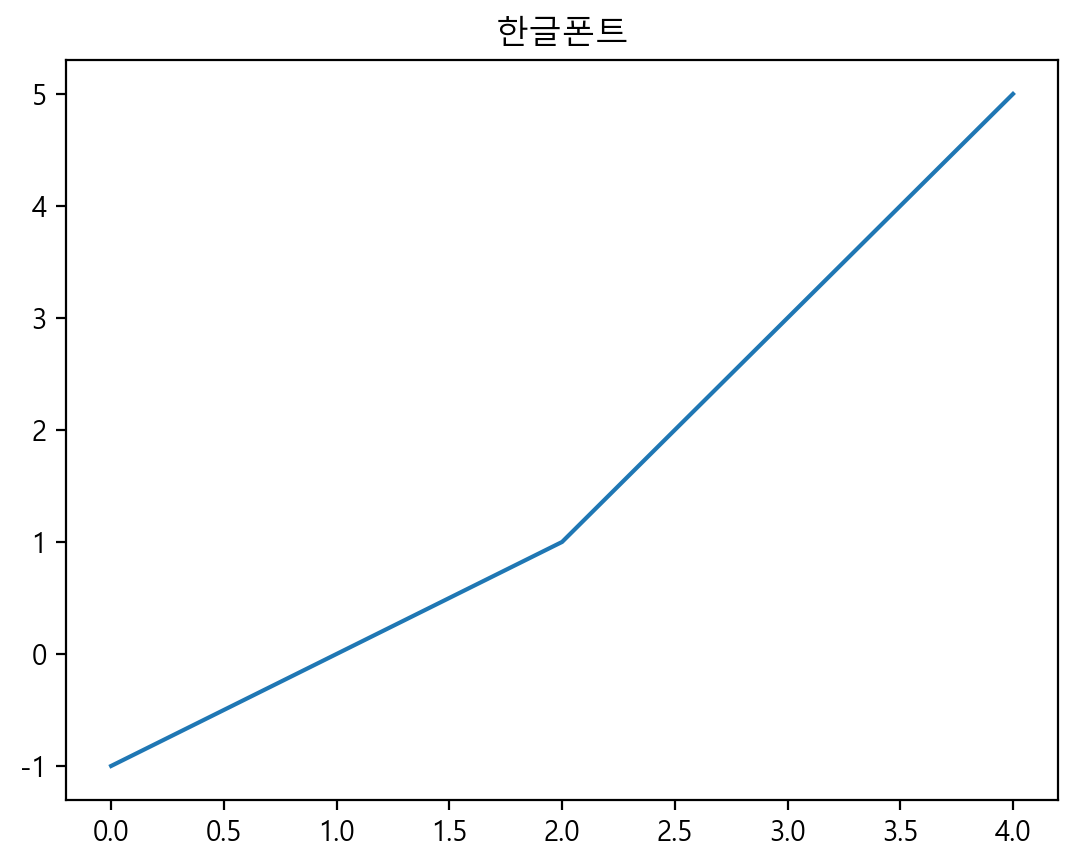

In [2]:
# 한글 안깨지게, 특수문자 안깨지게, 한글 선명하게
plt.rc("font", family="Malgun Gothic")
plt.rc("axes", unicode_minus=False)

# 폰트가 선명하게 보이도록 retina 설정
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats("retina")

# 한글폰트와 마이너스 폰트 설정 확인
pd.Series([-1, 0, 1, 3, 5]).plot(title="한글폰트")

# 지수 마이너스 유니코드 안깨지게
import matplotlib as mpl
mpl.rcParams['axes.unicode_minus'] = False

# 경고메시지 스킵
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('nail_market_v2.csv')

In [4]:
# utc 날짜컬럼으로 변환 (이렇게 해야 UTC기준이라는 전제 반영가능)
df['event_time'] = pd.to_datetime(df['event_time'], utc=True, format='%Y-%m-%d %H:%M:%S%z')
df['event_time'] = df['event_time'].dt.tz_convert('Europe/Moscow')  # +03:00 zone

# 기본 전처리 + 메모리 절약
df['event_date'] = df['event_time'].dt.date
df['event_hour'] = df['event_time'].dt.hour
df['event_type'] = df['event_type'].astype('category')
df['brand'] = df['brand'].astype('category')

In [5]:
display(df.info(),
        df.tail(),
        df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7595814 entries, 0 to 7595813
Data columns (total 10 columns):
 #   Column        Dtype                        
---  ------        -----                        
 0   event_time    datetime64[ns, Europe/Moscow]
 1   event_type    category                     
 2   product_id    int64                        
 3   category_id   int64                        
 4   brand         category                     
 5   price         float64                      
 6   user_id       int64                        
 7   user_session  object                       
 8   event_date    object                       
 9   event_hour    int32                        
dtypes: category(2), datetime64[ns, Europe/Moscow](1), float64(1), int32(1), int64(3), object(2)
memory usage: 449.1+ MB


None

,event_time,event_type,product_id,category_id,brand,price,user_id,user_session,event_date,event_hour
7595809,2020-02-29 23:59:58+03:00,remove_from_cart,5710530,1487580009622143014,irisk,0.63,622026701,54926d92-0446-4577-b923-a7309a5a8a52,2020-02-29,23
7595810,2020-02-29 23:59:58+03:00,remove_from_cart,5710530,1487580009622143014,irisk,0.63,622026701,54926d92-0446-4577-b923-a7309a5a8a52,2020-02-29,23
7595811,2020-02-29 23:59:59+03:00,cart,5700037,1487580009286598681,runail,0.40,495882061,2ad87792-8da8-45e1-94ba-74cb133df9ab,2020-02-29,23
7595812,2020-02-29 23:59:59+03:00,remove_from_cart,5700037,1487580009286598681,runail,0.40,495882061,2ad87792-8da8-45e1-94ba-74cb133df9ab,2020-02-29,23
7595813,2020-02-29 23:59:59+03:00,view,5857346,1487580005134238553,runail,2.78,621650836,d8085ca3-179a-4804-b53d-735be226323a,2020-02-29,23


event_time         0
event_type         0
product_id         0
category_id        0
brand              0
price              0
user_id            0
user_session    1289
event_date         0
event_hour         0
dtype: int64

In [6]:
df['price'].describe()

count    7.595814e+06
mean     7.264515e+00
std      1.404712e+01
min      6.000000e-02
25%      2.290000e+00
50%      3.970000e+00
75%      6.030000e+00
max      3.076000e+02
Name: price, dtype: float64

In [7]:
# user_session 결측값 이벤트 분포 확인
total = len(df)
miss = df['user_session'].isna().sum()
print("missing:", miss, "ratio:", miss/total)

# 결측이 어떤 이벤트에 몰려있는지
print(df[df['user_session'].isna()]['event_type'].value_counts())

# 브랜드 분포 확인
print(df[df['user_session'].isna()]['brand'].value_counts().head())

missing: 1289 ratio: 0.00016969873143286553
event_type
cart                1039
remove_from_cart     245
view                   5
purchase               0
Name: count, dtype: int64
brand
irisk       306
runail      271
grattol     207
haruyama     73
cnd          64
Name: count, dtype: int64


In [8]:
# 퍼널/세션 분석용 클린 데이터
df_sess = df[df['user_session'].notna()].copy()

# **네일 시장 핵심 인사이트**

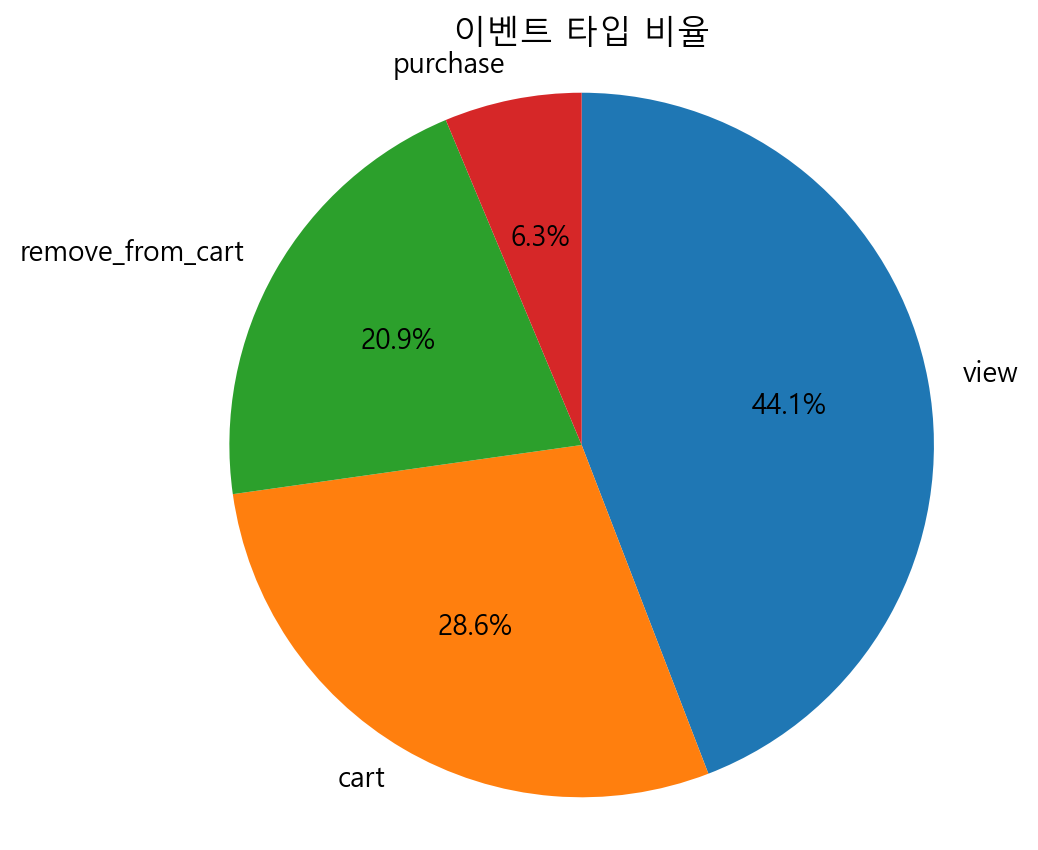

In [9]:
# 이벤트 타입 비율 파이차트
counts = df['event_type'].value_counts()

plt.figure(figsize=(5,5))
plt.pie(
    counts.values,
    labels=counts.index,
    autopct='%1.1f%%',
    startangle=90,
    counterclock=False
)
plt.title('이벤트 타입 비율')
plt.axis('equal')
plt.show()

# 태블로에서 분석할때는 view에 해당하는 값이 100%가 되게 해야함 100%의 뷰 중 액션이 있는것이므로
# view -> pur
# view -> cart -> pur

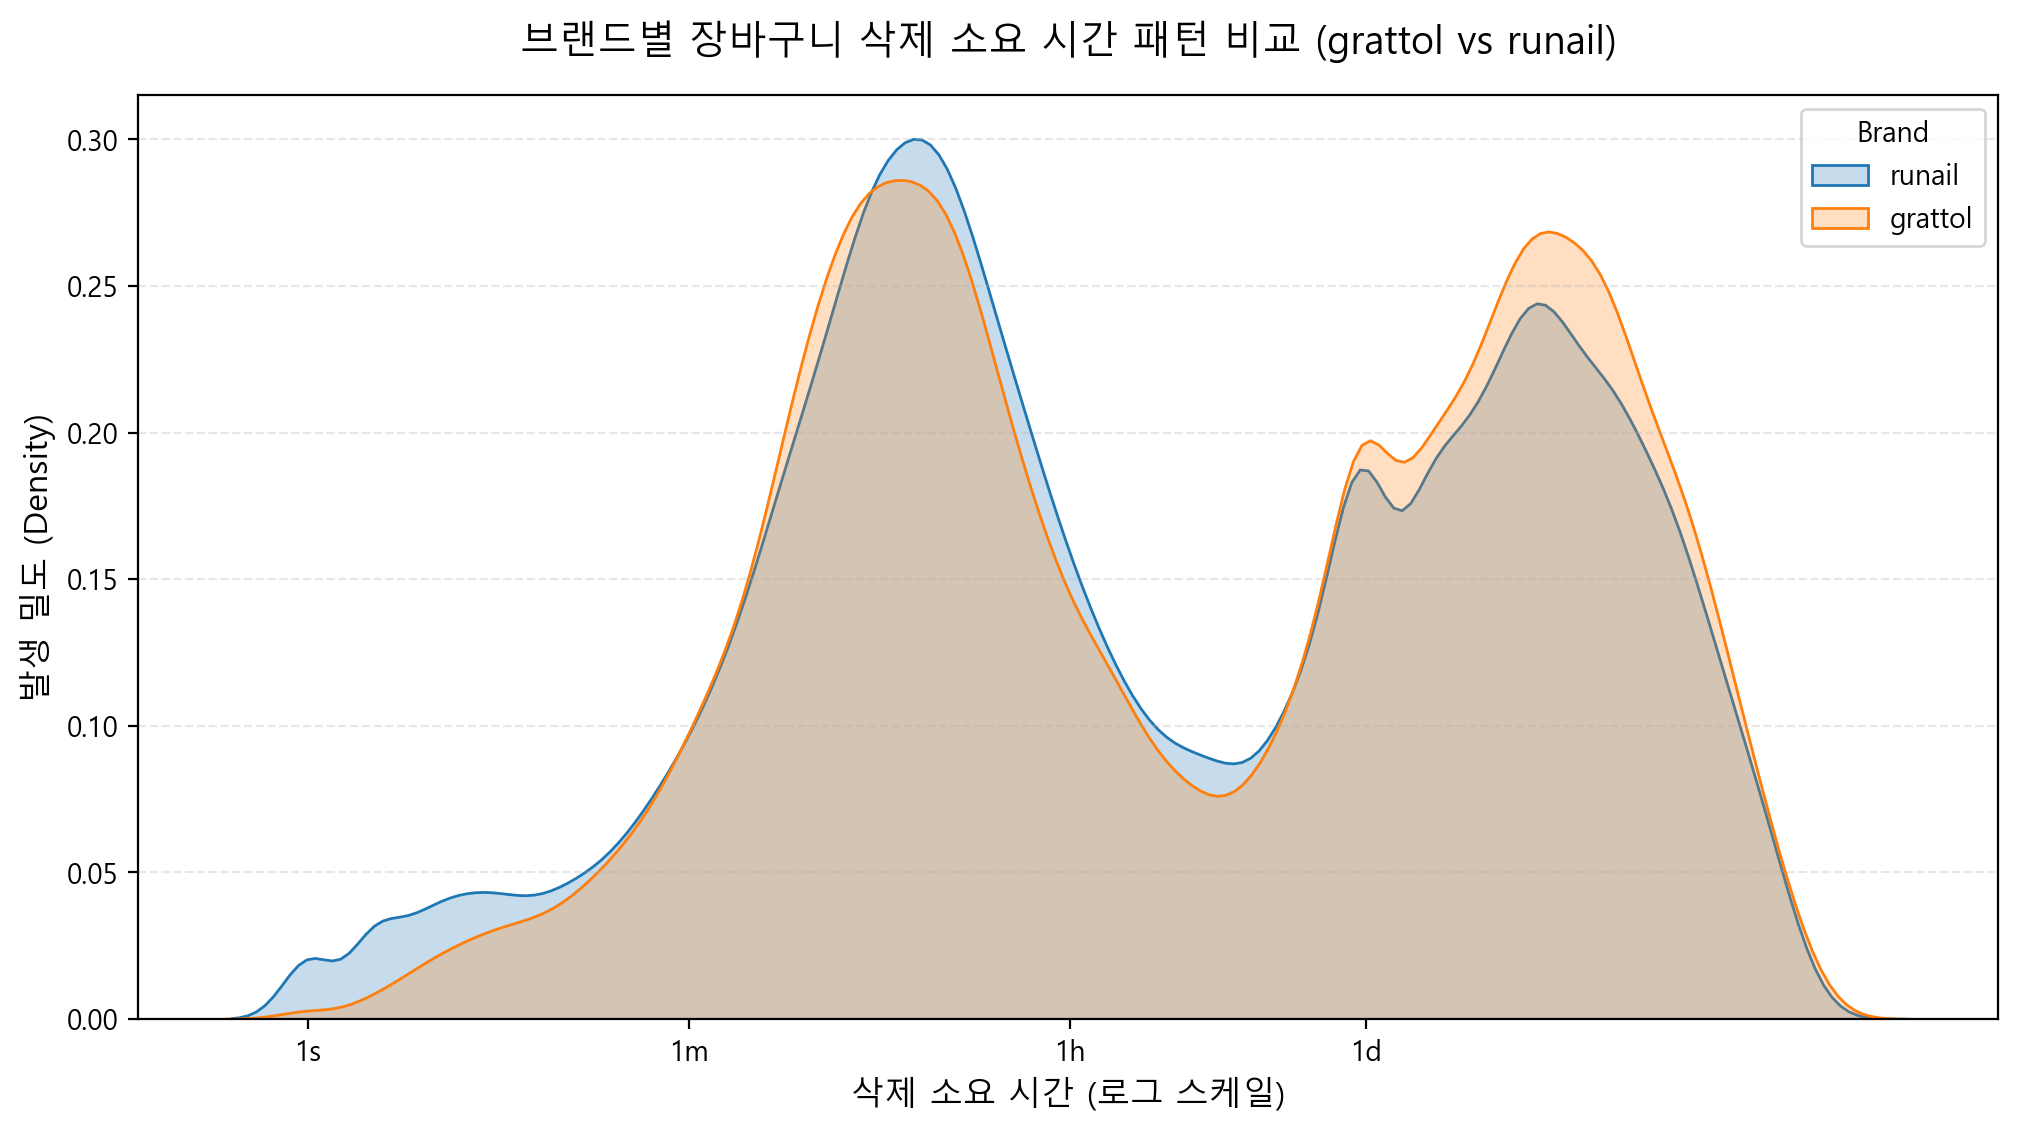

In [10]:
# cart와 remove_from_cart 이벤트만 모은 cart_actions를 정의합니다.
cart_actions = df[df['event_type'].isin(['cart', 'remove_from_cart'])].copy()

#  담기(cart) 직후 발생한 삭제(remove) 건만 추적
# 단순 삭제가 아닌, '담고 나서 고민하다 뺀' 시간을 측정하기 위해 직전 행의 이벤트를 참조함
cart_actions['prev_event'] = cart_actions.groupby(['user_id', 'product_id'])['event_type'].shift(1)
cart_actions['duration'] = cart_actions.groupby(['user_id', 'product_id'])['event_time'].diff().dt.total_seconds()

# '담기 -> 삭제' 시퀀스가 성립하는 유효 데이터만 필터링
final_gap_brand = cart_actions[
    (cart_actions['event_type'] == 'remove_from_cart') & 
    (cart_actions['prev_event'] == 'cart')
].copy()

# 분석 대상 브랜드 한정 및 결측치 제거
final_gap_brand = final_gap_brand[final_gap_brand['brand'].isin(['runail', 'grattol'])]
final_gap_brand = final_gap_brand.dropna(subset=['duration'])

# 시각화: 로그 스케일을 활용한 브랜드별 생존 시간 분포 비교
plt.figure(figsize=(12, 6))
for b in ['runail', 'grattol']:
    subset = final_gap_brand[final_gap_brand['brand'] == b]
    
    if not subset.empty:
        # bw_adjust=0.8: 곡선의 세밀도를 조정하여 원본의 뾰족한 피크 특성을 재현
        sns.kdeplot(np.log10(subset['duration'] + 1), label=b, fill=True, bw_adjust=0.8)

# X축: 1초, 1분, 1시간, 1일 단위로 로그 변환하여 가독성 확보
plt.xticks(np.log10([1, 60, 3600, 3600*24]), ['1s', '1m', '1h', '1d'])

# 차트 디테일 설정
plt.title('브랜드별 장바구니 삭제 소요 시간 패턴 비교 (grattol vs runail)', fontsize=14, pad=15)
plt.xlabel('삭제 소요 시간 (로그 스케일)', fontsize=12)
plt.ylabel('발생 밀도 (Density)', fontsize=12)
plt.legend(title='Brand')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

In [11]:
# 1. 유저별 첫 View와 첫 Purchase 시간 비교
first_view = df[df['event_type'] == 'view'].groupby(['user_id', 'product_id'])['event_time'].min().reset_index()
first_purchase = df[df['event_type'] == 'purchase'].groupby(['user_id', 'product_id'])['event_time'].min().reset_index()

# 2. 두 데이터 결합 (조회 후 구매한 케이스)
speed_df = pd.merge(first_view, first_purchase, on=['user_id', 'product_id'], suffixes=('_view', '_purchase'))

# 3. 결정 속도 계산
speed_df['decision_time_min'] = (speed_df['event_time_purchase'] - speed_df['event_time_view']).dt.total_seconds() / 60

# 4. 결과 해석 (10분 이내 결제 비중)
quick_buyers = speed_df[speed_df['decision_time_min'] <= 10].shape[0] / speed_df.shape[0] * 100
print(f"조회 후 10분 이내 즉시 구매 비중: {quick_buyers:.2f}%")

조회 후 10분 이내 즉시 구매 비중: 22.28%


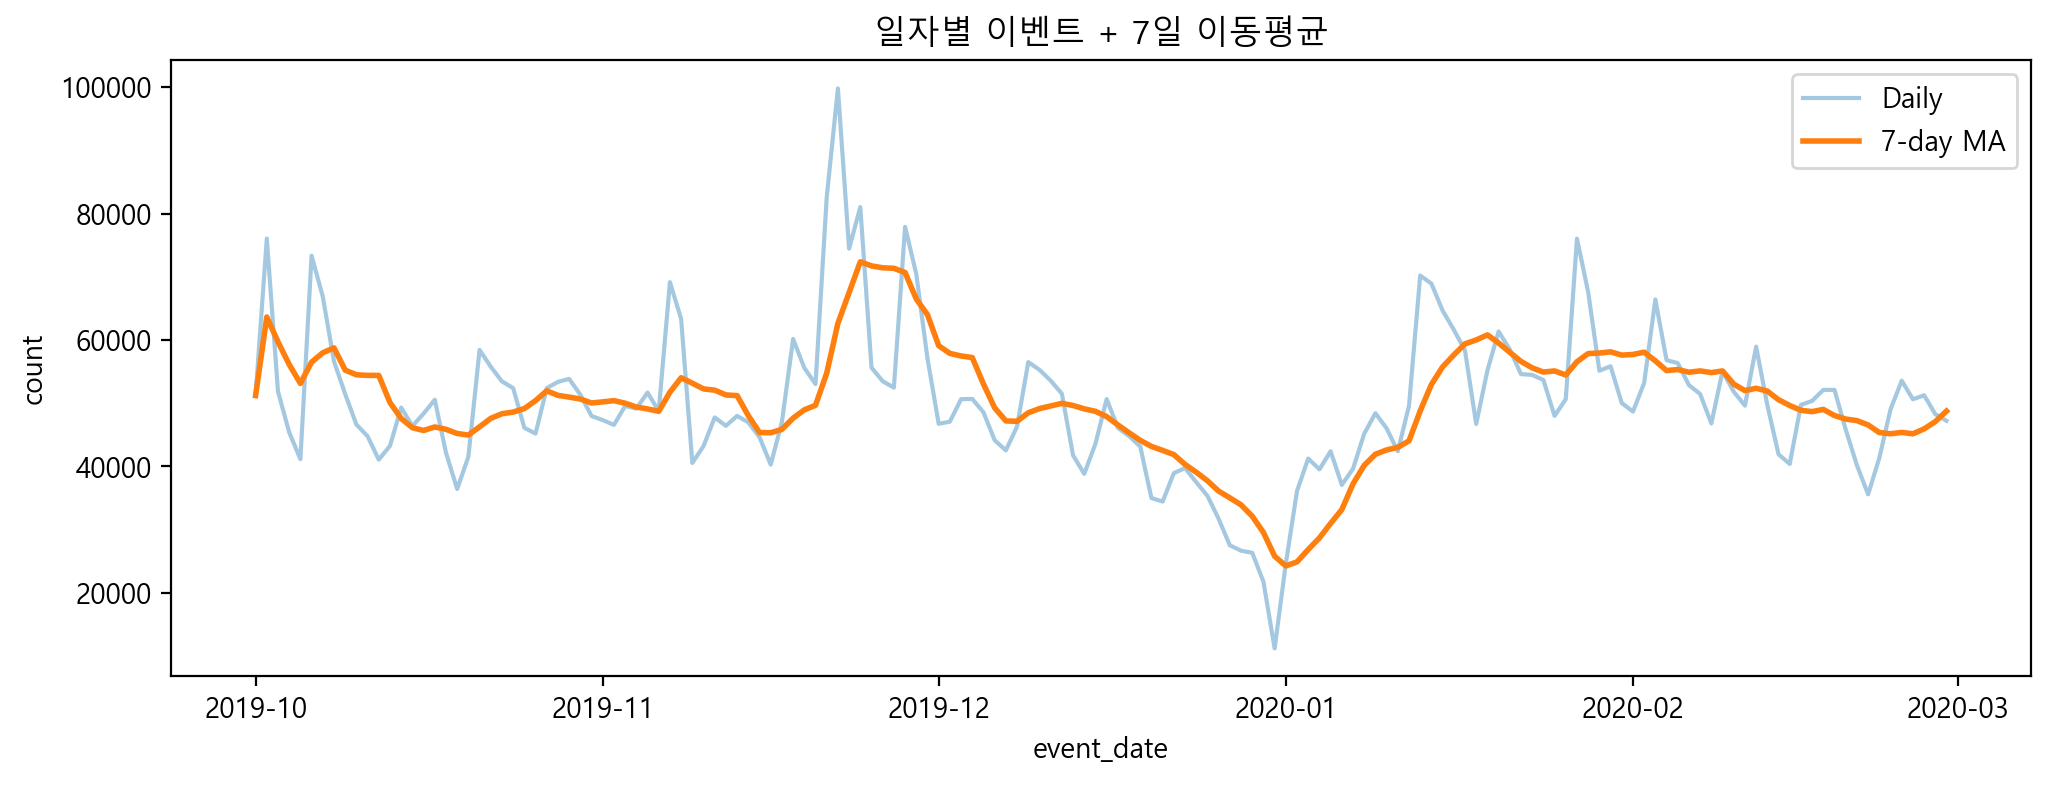

In [12]:
# 일자별 이벤트 + 이동평균
daily = df.groupby('event_date').size().sort_index()

window = 7  # 필요하면 14, 30 등으로 변경
daily_ma = daily.rolling(window=window, min_periods=1).mean()

plt.figure(figsize=(12,4))
daily.plot(alpha=0.4, label='Daily')
daily_ma.plot(linewidth=2, label=f'{window}-day MA')
plt.title('일자별 이벤트 + 7일 이동평균')
plt.ylabel('count')
plt.legend()
plt.show()

1. 11월 중순부터 수요가 급격히 상승하는것으로 보아, "추운 지역이라서 겨울에 손톱 보호를 위해 젤네일로 덮으려고 한다"는 해석은 적절해보인다 <br>
2. 1월의 새해+동방정교회 성탄절 1주일 연휴때문인지, 저 시기에 구매가 매우 적다<br>
3. 이후 코로나 영향인지 점점 수요가 하락함. 3월 여성의날을 기점으로 전환국면을 만들 필요성이 있음



+ 건강검진 마지노선 시기에는 네일을 못하니까 비수기일것이라는 가설도 충분히 일리가 있음 <br>
디스판세리자치야(Диспансеризация) 라는 전국민 대상 정기 건강검진 제도가 있음 <br>
만 18세~39세: 3년에 한 번 무료 검진 <br>
만 40세 이상: 매년 한 번씩 무료 검진 <br>
3년 주기 대상자의 경우 해당 연도 12월까지 검진을 완료해야 하므로, 4분기(10월~12월)에 수검자가 몰리는 현상이 발생


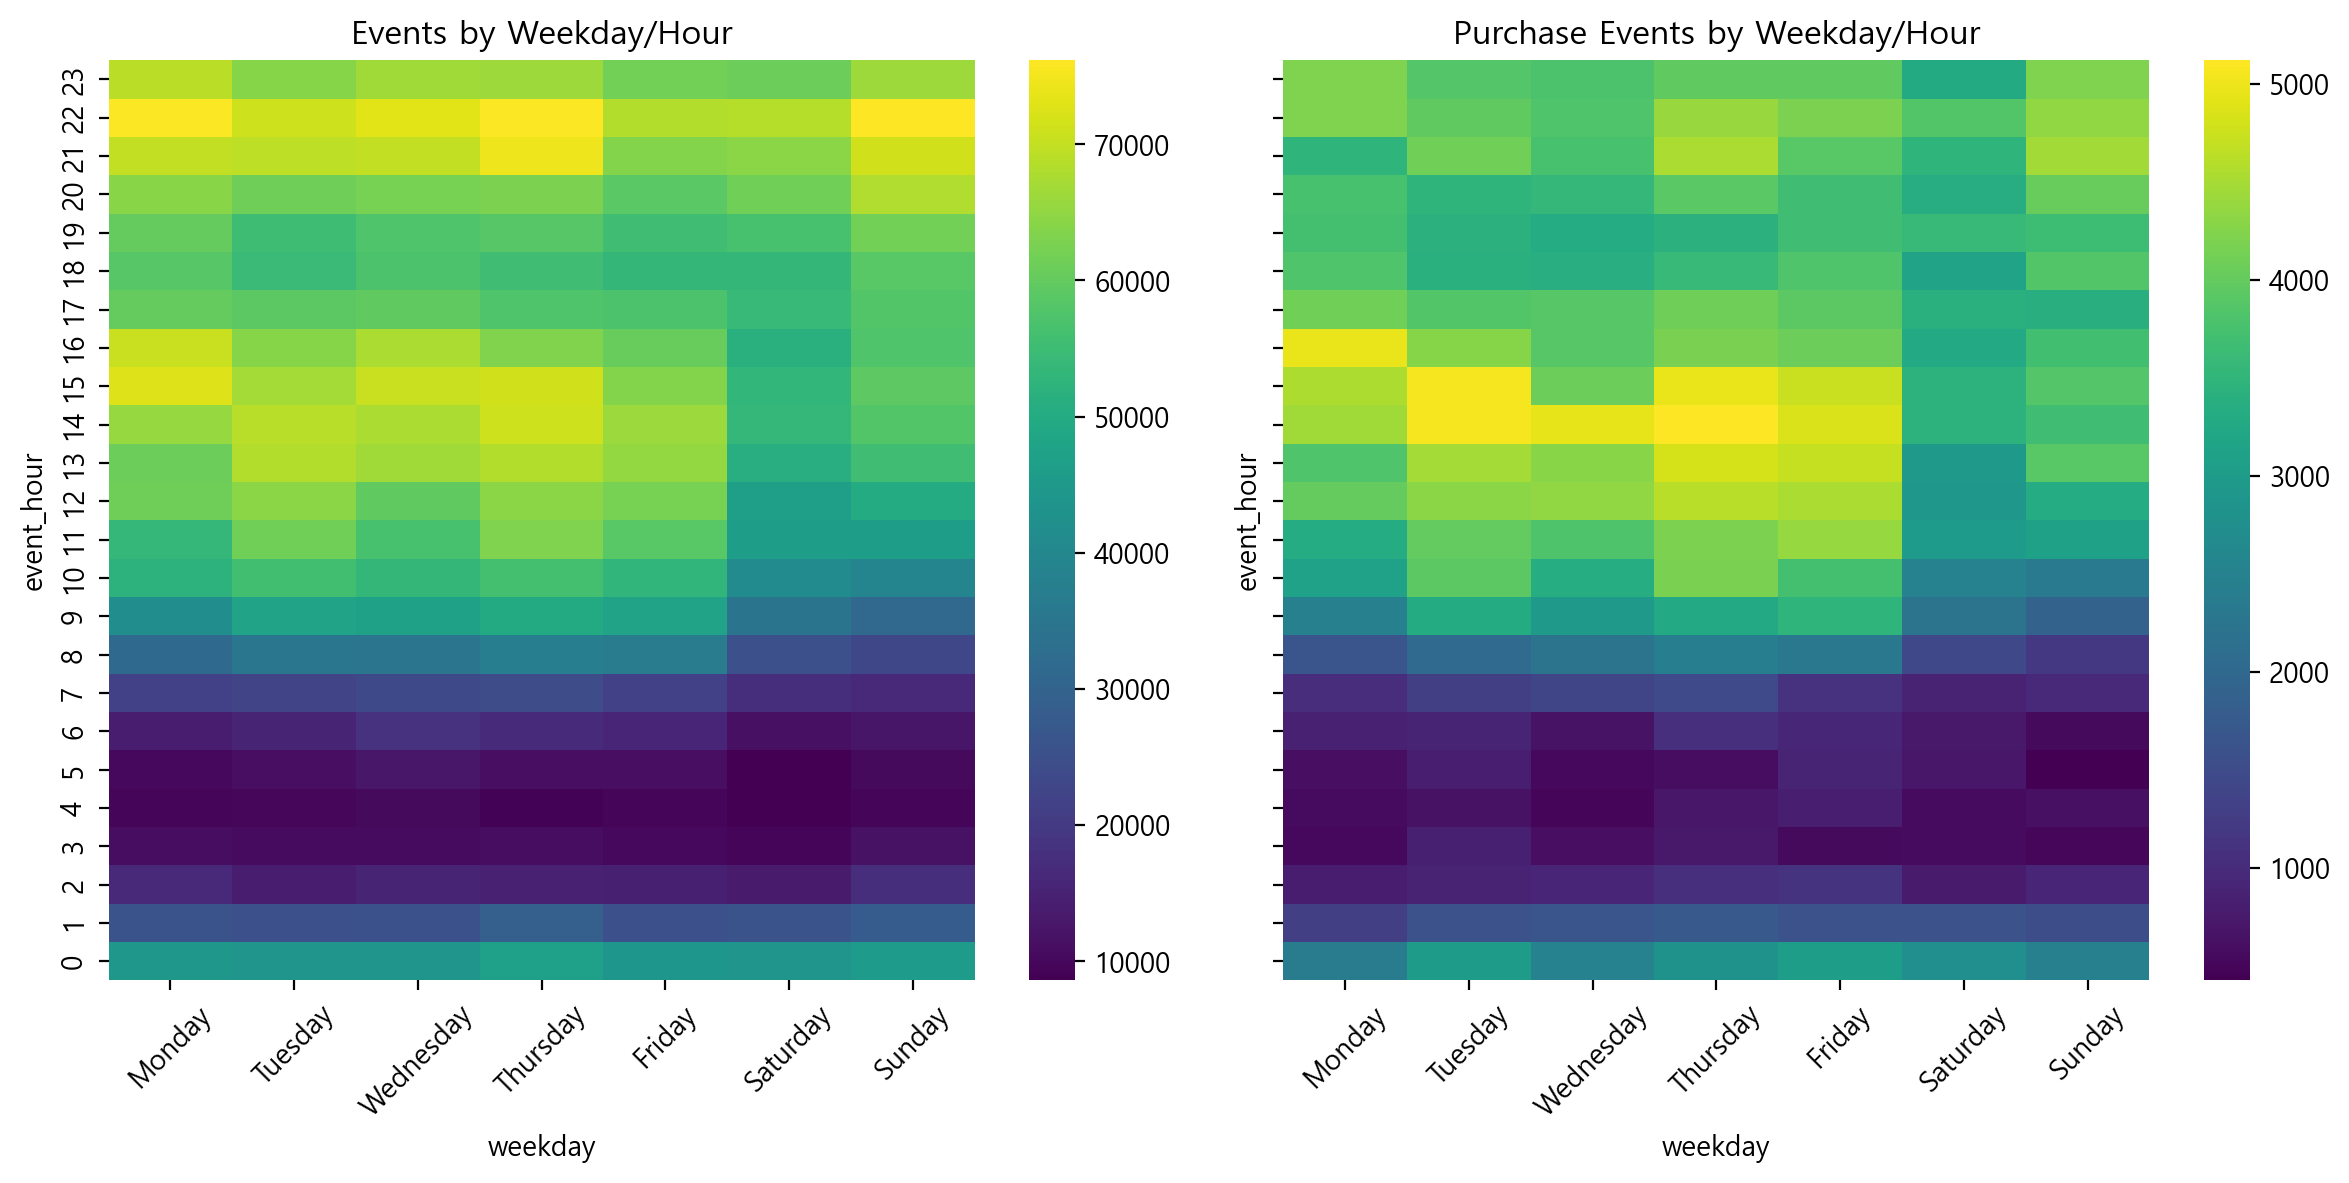

In [41]:
# 요일/시간별 이벤트 체크 히트맵

df['weekday'] = df['event_time'].dt.day_name()
pivot = df.groupby(['weekday','event_hour']).size().unstack(fill_value=0)
pivot_all = pivot.reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])


# 요일/시간 히트맵 (purchase 기준)
purchase = df[df['event_type'] == 'purchase'].copy()

purchase['weekday'] = purchase['event_time'].dt.day_name()
purchase['event_hour'] = purchase['event_time'].dt.hour

pivot = purchase.groupby(['weekday','event_hour']).size().unstack(fill_value=0)
pivot_purchase = pivot.reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])


fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# 전체 이벤트
ax = axes[0]
sns.heatmap(pivot_all.T, cmap='viridis', ax=ax)
ax.invert_yaxis()
ax.set_title('Events by Weekday/Hour')
ax.tick_params(axis='x', rotation=45)

# purchase 이벤트
ax = axes[1]
sns.heatmap(pivot_purchase.T, cmap='viridis', ax=ax)
ax.invert_yaxis()
ax.set_title('Purchase Events by Weekday/Hour')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()



### 위 히트맵들을 보면, 밤에는 아이쇼핑이 많고 평일 오후 점심시간에 최종액션이 일어나는것을 볼 수 있다

- 금토일 오후에 비어있는걸 보면 다차문화로 인해 유입이 적은것을 설명할 수 있을 것 같다
다차문화 (러시아 인구 70%가 별장보유)<br>
영주가 충신에게 하사하던 문화서 시작 / 사회주의 180평씩 나눠줌 / 경제난극복에 도움<br>
금~일은 별장에서 시간을 보냄

- 주타겟이 B2B 시장이다 보니 주말에는 손님응대, 평일에 구매?

# **grattol vs runail**

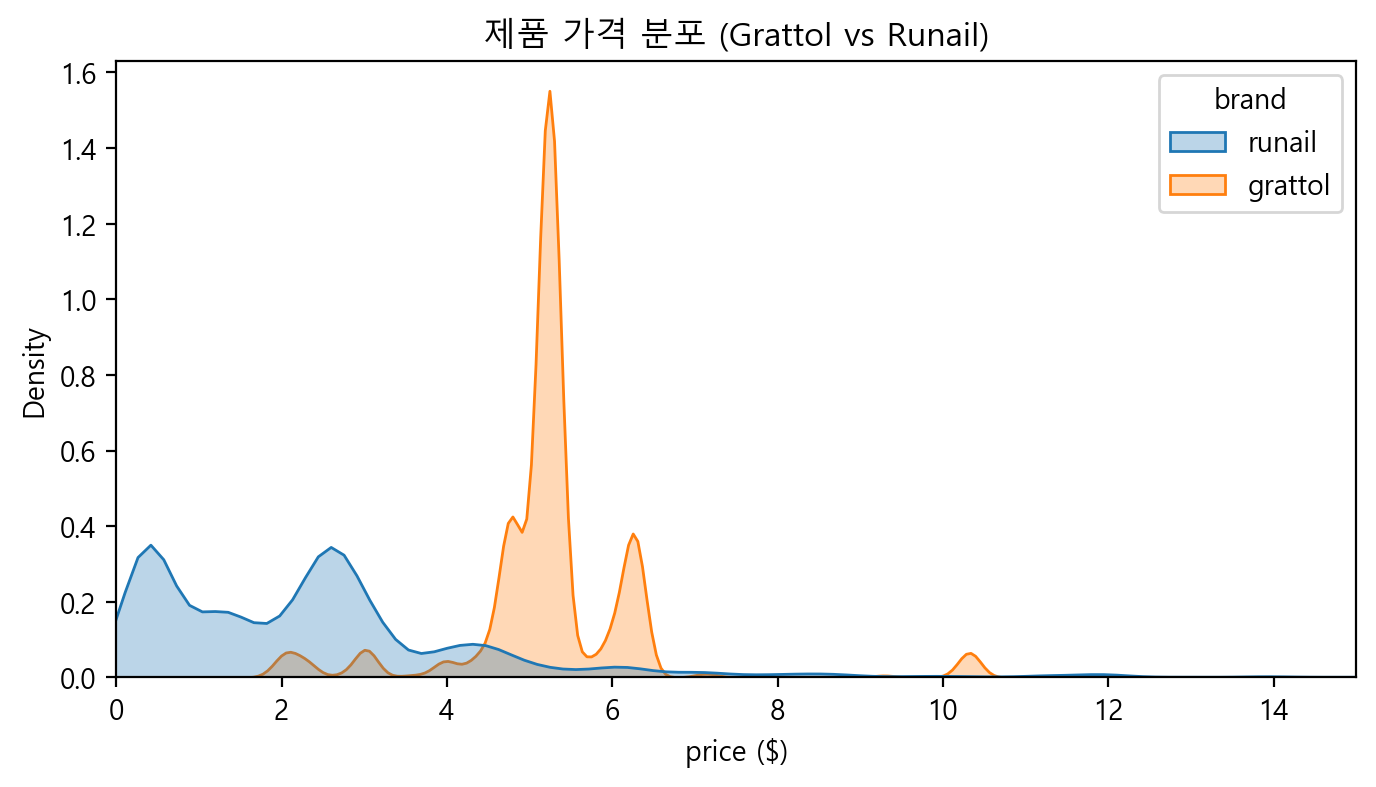

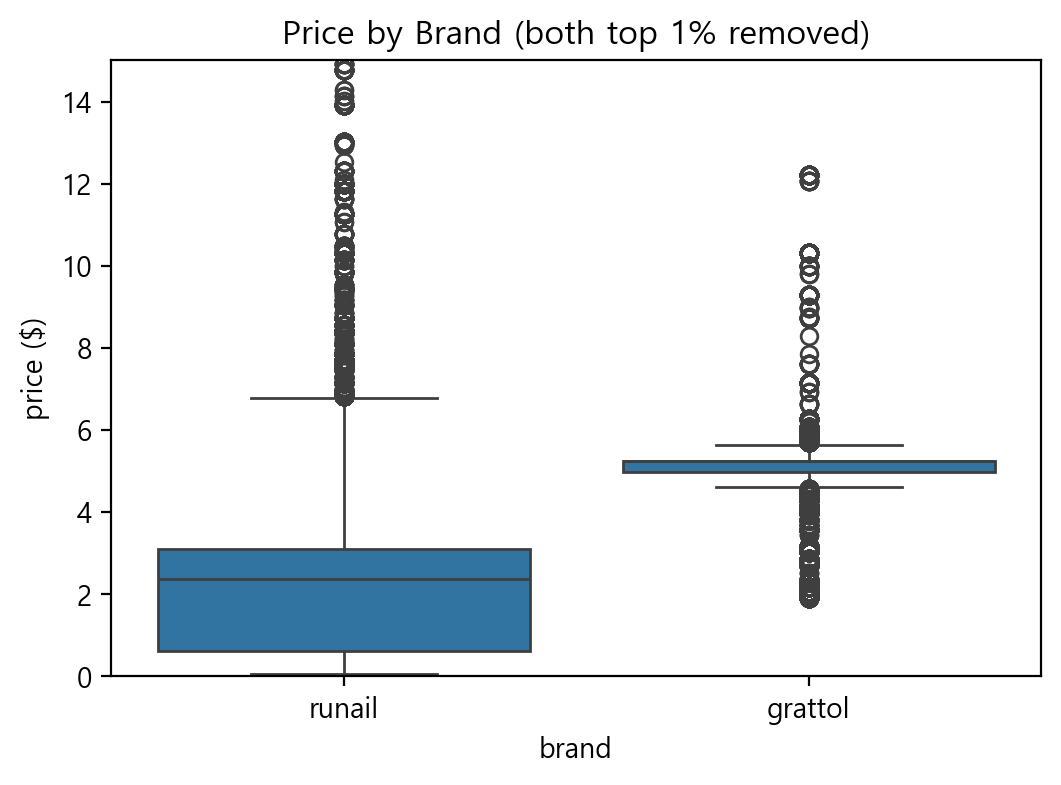

In [14]:
# 구매 가격대 비교 (purchase 기준)

purchase = df[df['event_type'] == 'purchase'].copy()
focus = purchase[purchase['brand'].isin(['runail','grattol'])].copy()
focus['brand'] = focus['brand'].astype(str)

# 브랜드별 99퍼센타일
p99 = focus.groupby('brand')['price'].quantile(0.99)

# 각 브랜드별로 상위 1% 제거
focus_trim = focus[
    focus.apply(lambda r: r['price'] <= p99[r['brand']], axis=1)
]

plt.figure(figsize=(8,4))
sns.kdeplot(data=focus_trim, x='price', hue='brand', common_norm=False, fill=True, alpha=0.3)
plt.title('제품 가격 분포 (Grattol vs Runail)')
plt.xlabel('price ($)')
plt.xlim(0, 15)
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(data=focus_trim, x='brand', y='price', order=['runail','grattol'])
plt.title('Price by Brand (both top 1% removed)')
plt.ylim(0, 15)
plt.ylabel('price ($)')
plt.show()


runail에 적게 팔린 고가제품이 거슬려 편하게 보기 위해 상위 1%씩을 제외하고 보았다 <br>
grattol은 제품 포지서닝이 명확하고 평균 객단가가 높다 <br>
runail은 다양한 제품군을 취급하기에 가격이 넓은 분산을 가지고, 보통 일회용품 구매가 많은것으로 보인다

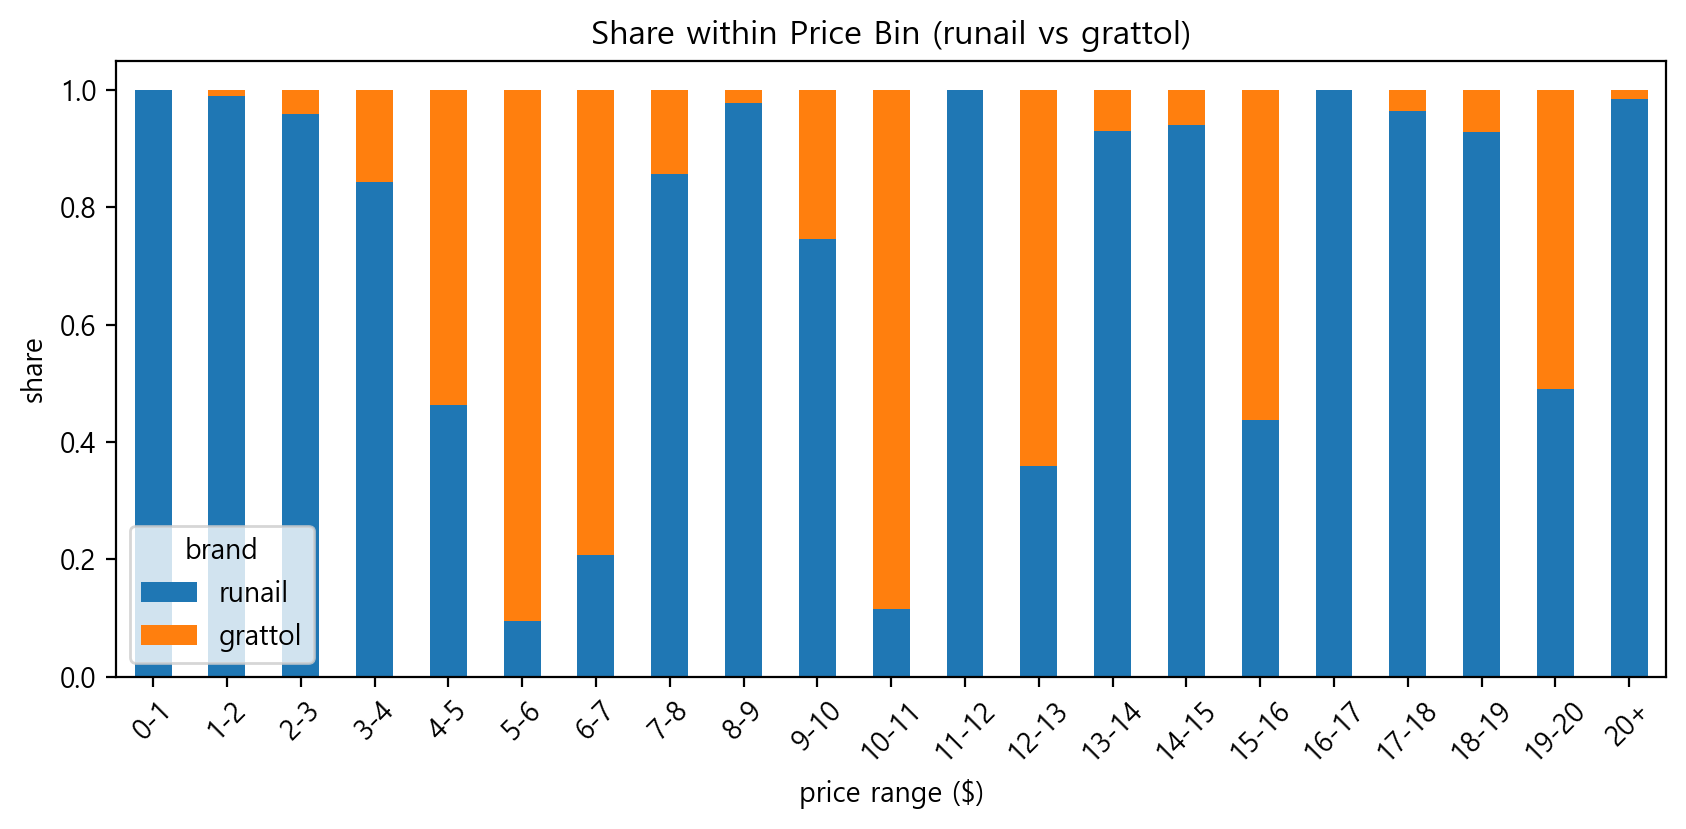

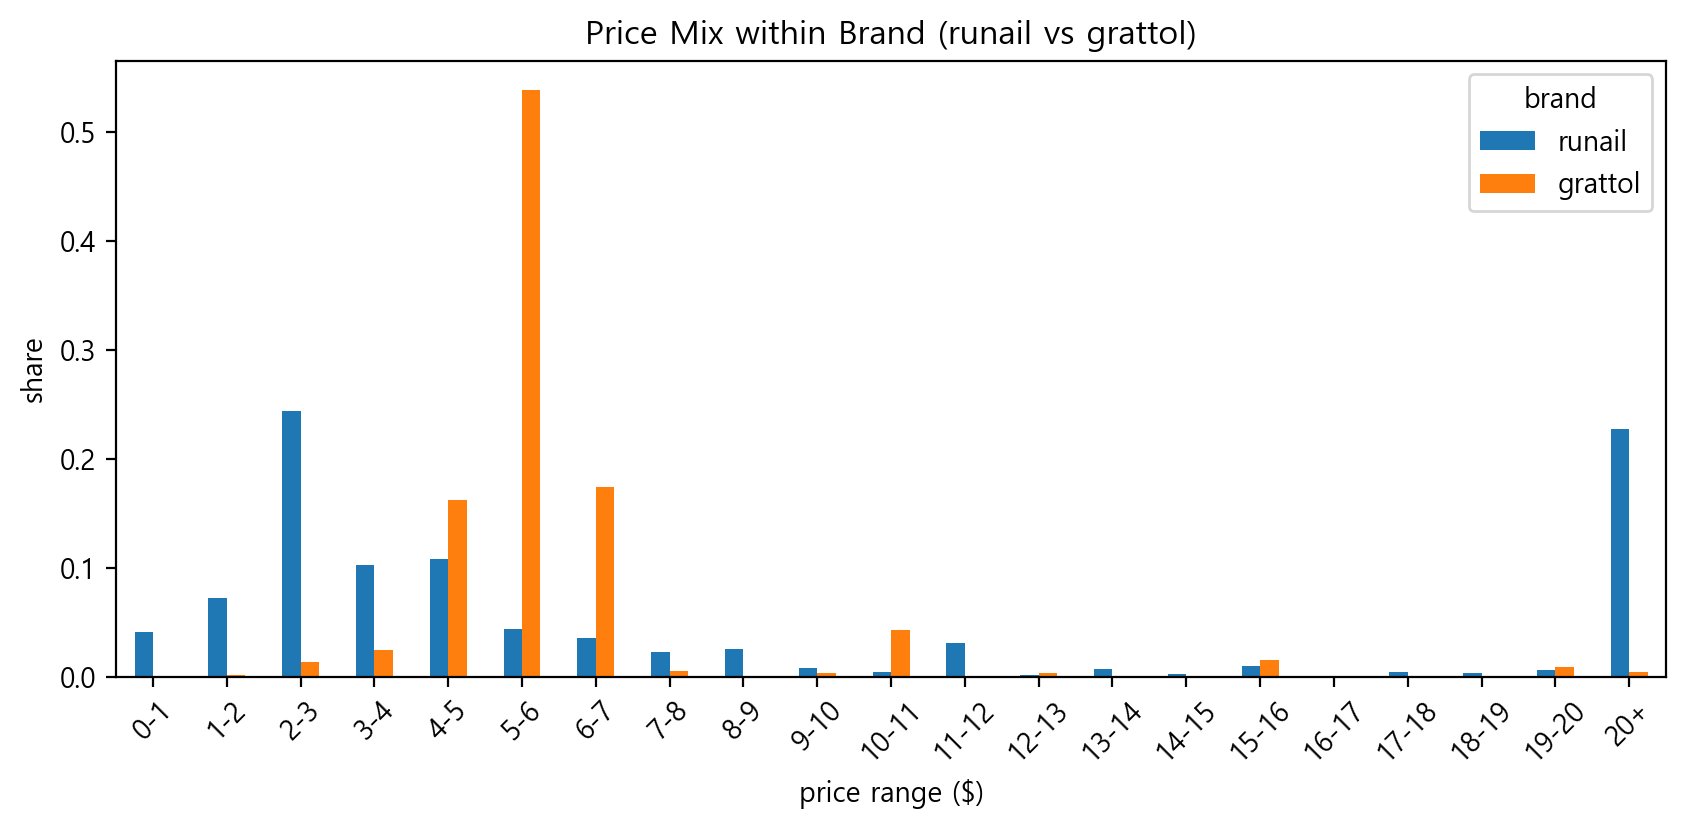

In [15]:
# 1) 가격대 포지셔닝: runail vs grattol
purchase = df[df['event_type'] == 'purchase'].copy()
focus = purchase[purchase['brand'].isin(['runail','grattol'])].copy()
focus['brand'] = focus['brand'].astype(str)

bins = list(range(0, 21)) + [float('inf')]
labels = [f'{i}-{i+1}' for i in range(0, 20)] + ['20+']
focus['price_bin'] = pd.cut(focus['price'], bins=bins, labels=labels, right=False, include_lowest=True)

# 가격대별 매출 합계
rev_by_bin = focus.groupby(['price_bin','brand'])['price'].sum().unstack(fill_value=0)
rev_by_bin = rev_by_bin[['runail','grattol']]

# 가격대별 브랜드 점유율 (bin 내부 기준)
share_in_bin = rev_by_bin.div(rev_by_bin.sum(axis=1), axis=0)

# 브랜드 내부 가격대 구성 (brand 내부 기준)
share_in_brand = rev_by_bin.div(rev_by_bin.sum(axis=0), axis=1)

# 기회 점수: runail이 강하고 시장 규모가 큰 bin
opp = pd.DataFrame({
    'bin_revenue': rev_by_bin.sum(axis=1),
    'runail_share_in_bin': share_in_bin['runail'],
    'grattol_share_in_bin': share_in_bin['grattol'],
    'grattol_mix': share_in_brand['grattol'],
    'runail_mix': share_in_brand['runail'],
})
opp['share_gap'] = opp['runail_share_in_bin'] - opp['grattol_share_in_bin']
opp['opportunity_score'] = opp['share_gap'] * opp['bin_revenue']

# 가격대별 브랜드 점유율(가격대 내부 기준)
share_in_bin.plot(kind='bar', stacked=True, figsize=(10,4))
plt.title('Share within Price Bin (runail vs grattol)')
plt.ylabel('share')
plt.xlabel('price range ($)')
plt.xticks(rotation=45)
plt.show()

# 브랜드 내부 구성비(브랜드별 매출 믹스)
share_in_brand.plot(kind='bar', figsize=(10,4))
plt.title('Price Mix within Brand (runail vs grattol)')
plt.ylabel('share')
plt.xlabel('price range ($)')
plt.xticks(rotation=45)
plt.show()


확실히 grattol은 특정 가격대 4 ~ 7 달러에 주력 상품이 몰려있다

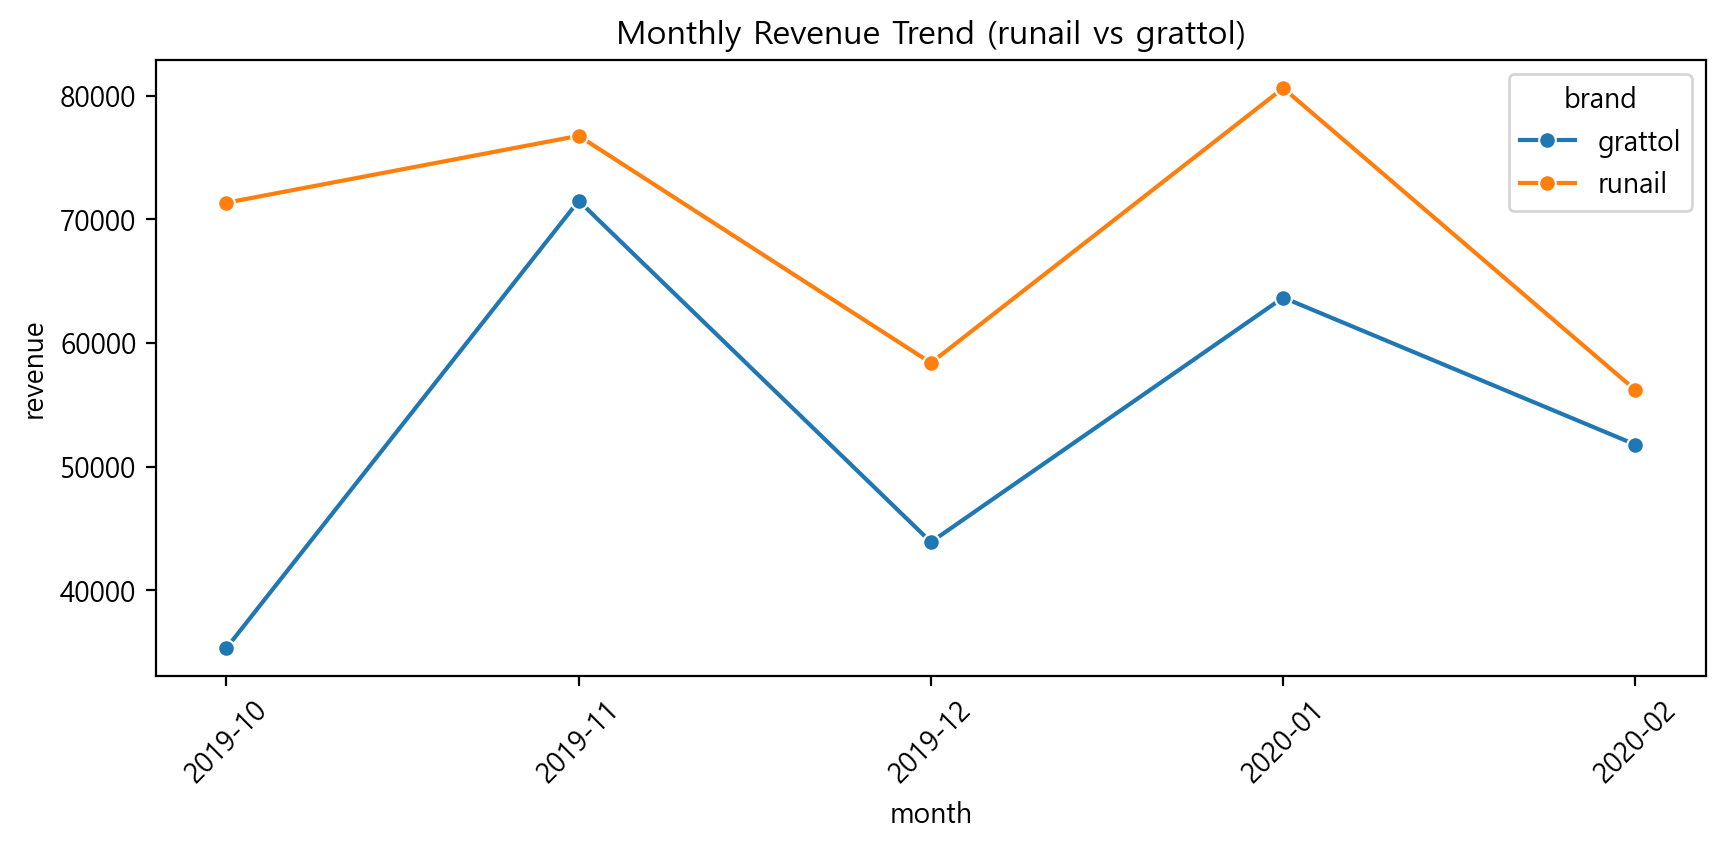

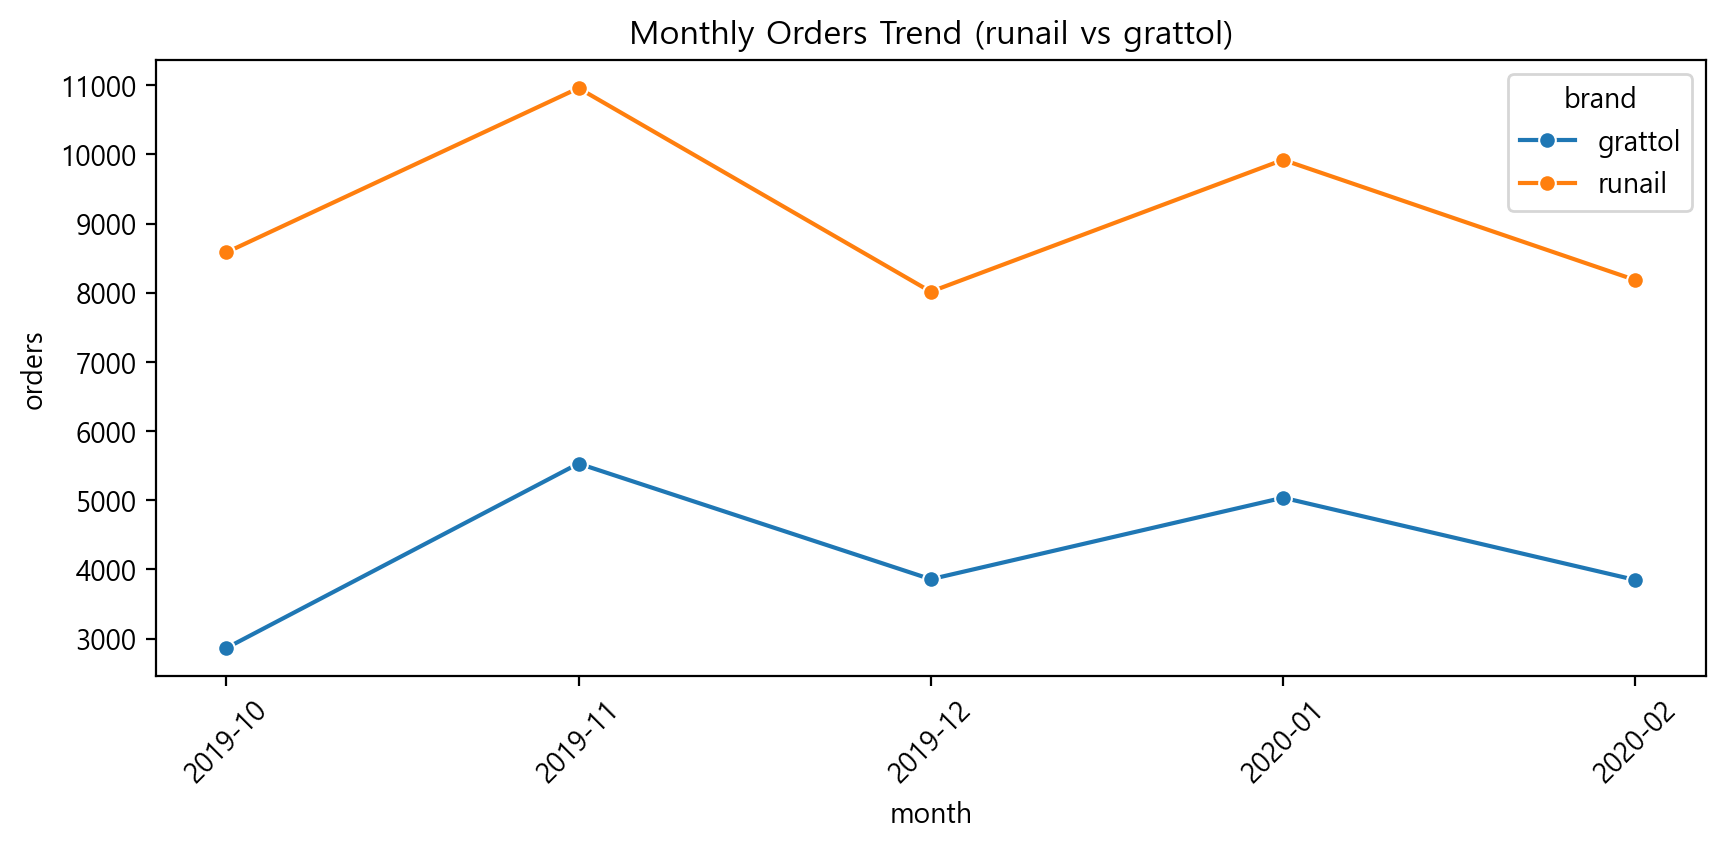

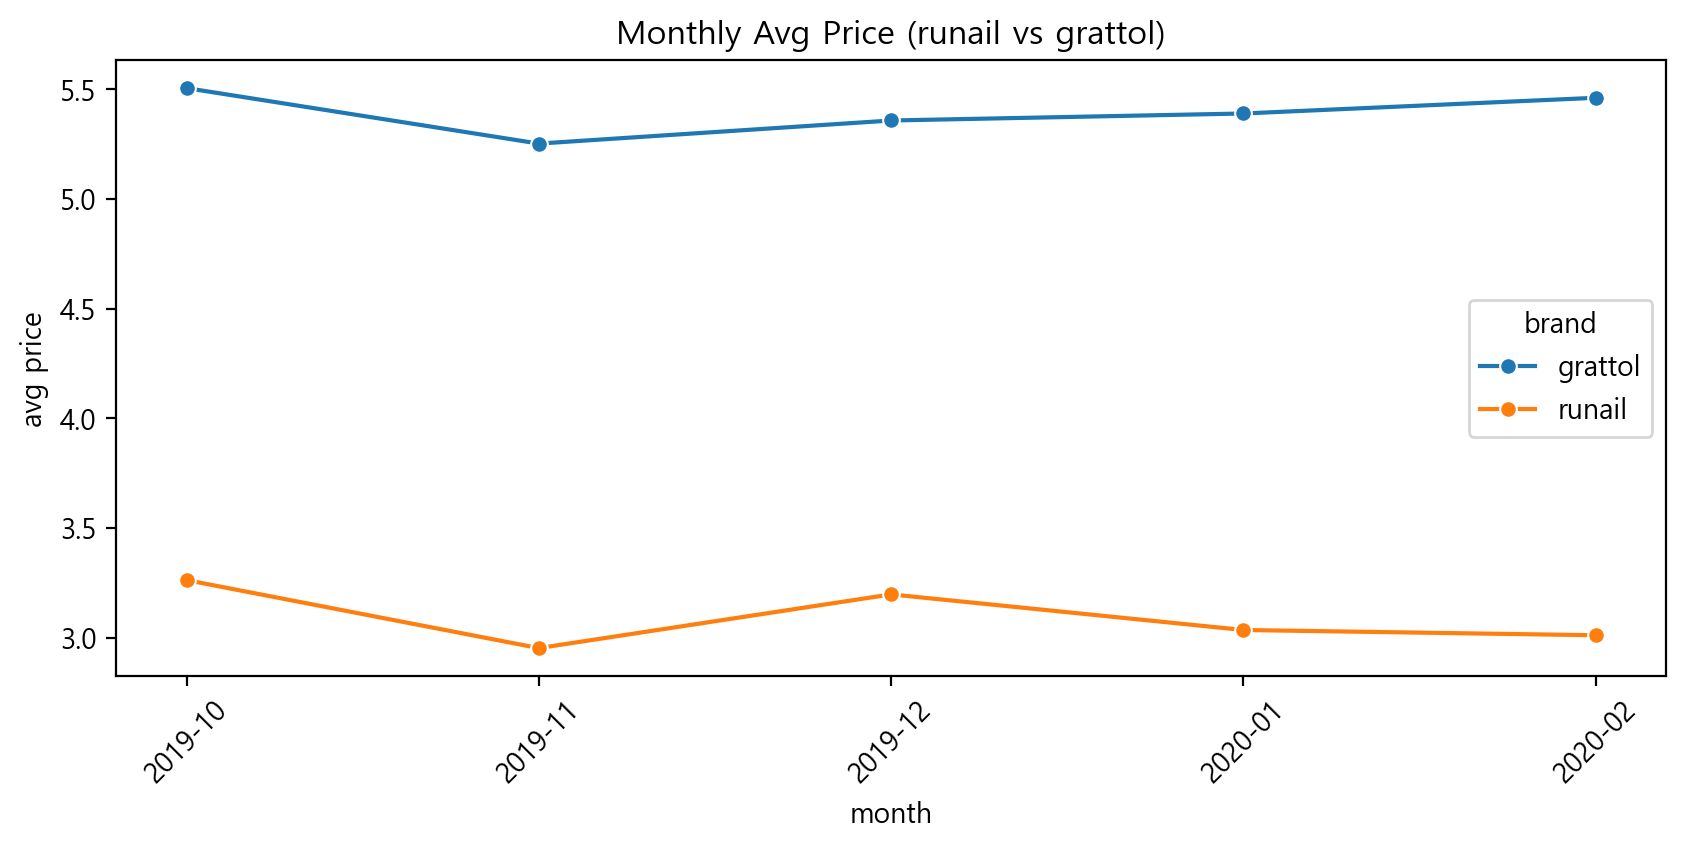

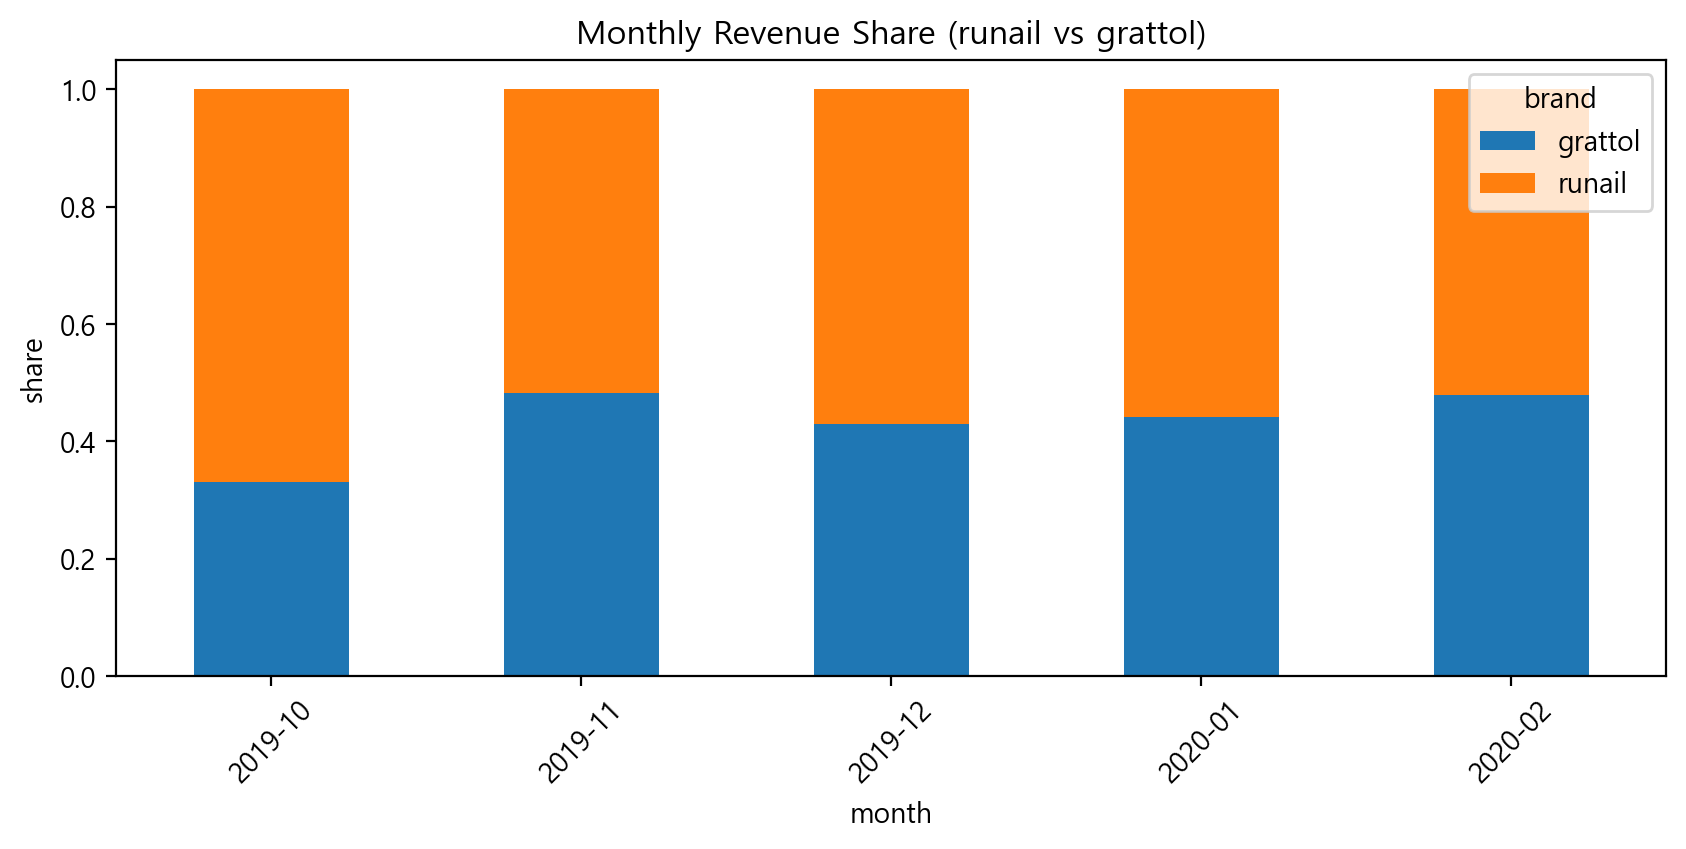

In [16]:
# 3) 시간/시즌 분석 (월별 추이)
purchase = df[df['event_type'] == 'purchase'].copy()
purchase = purchase[purchase['brand'].isin(['runail','grattol'])].copy()
purchase['brand'] = purchase['brand'].astype(str)

# 월 컬럼
purchase['month'] = purchase['event_time'].dt.to_period('M').astype(str)

# 월별 매출/건수/객단가
monthly = (purchase.groupby(['month','brand'])
           .agg(revenue=('price','sum'),
                orders=('user_session','nunique'),
                avg_price=('price','mean'))
           .reset_index())

# 월별 매출 점유율
share = (monthly.pivot(index='month', columns='brand', values='revenue')
                .fillna(0))
share_pct = share.div(share.sum(axis=1), axis=0)

# 시각화: 월별 매출 추이
plt.figure(figsize=(10,4))
sns.lineplot(data=monthly, x='month', y='revenue', hue='brand', marker='o')
plt.title('Monthly Revenue Trend (runail vs grattol)')
plt.xticks(rotation=45)
plt.ylabel('revenue')
plt.xlabel('month')
plt.show()

# 시각화: 월별 주문건수 추이
plt.figure(figsize=(10,4))
sns.lineplot(data=monthly, x='month', y='orders', hue='brand', marker='o')
plt.title('Monthly Orders Trend (runail vs grattol)')
plt.xticks(rotation=45)
plt.ylabel('orders')
plt.xlabel('month')
plt.show()

# 시각화: 월별 평균 객단가
plt.figure(figsize=(10,4))
sns.lineplot(data=monthly, x='month', y='avg_price', hue='brand', marker='o')
plt.title('Monthly Avg Price (runail vs grattol)')
plt.xticks(rotation=45)
plt.ylabel('avg price')
plt.xlabel('month')
plt.show()

# 시각화: 월별 매출 점유율
share_pct.plot(kind='bar', stacked=True, figsize=(10,4))
plt.title('Monthly Revenue Share (runail vs grattol)')
plt.ylabel('share')
plt.xlabel('month')
plt.xticks(rotation=45)
plt.show()

runail은 박리다매, grattol은 고리소매인것을 볼 수 있다

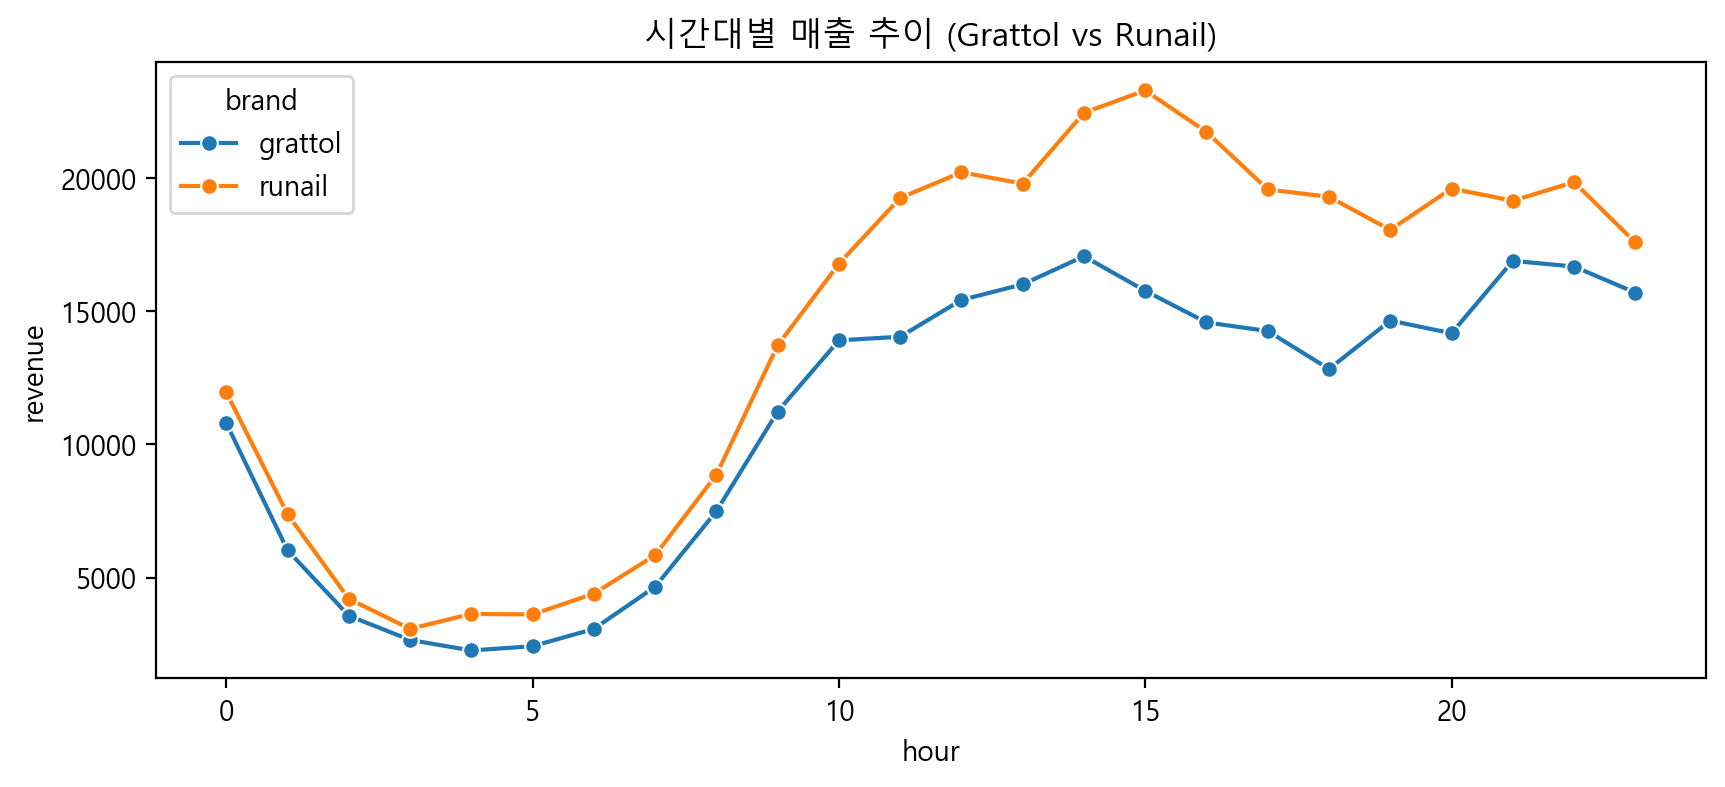

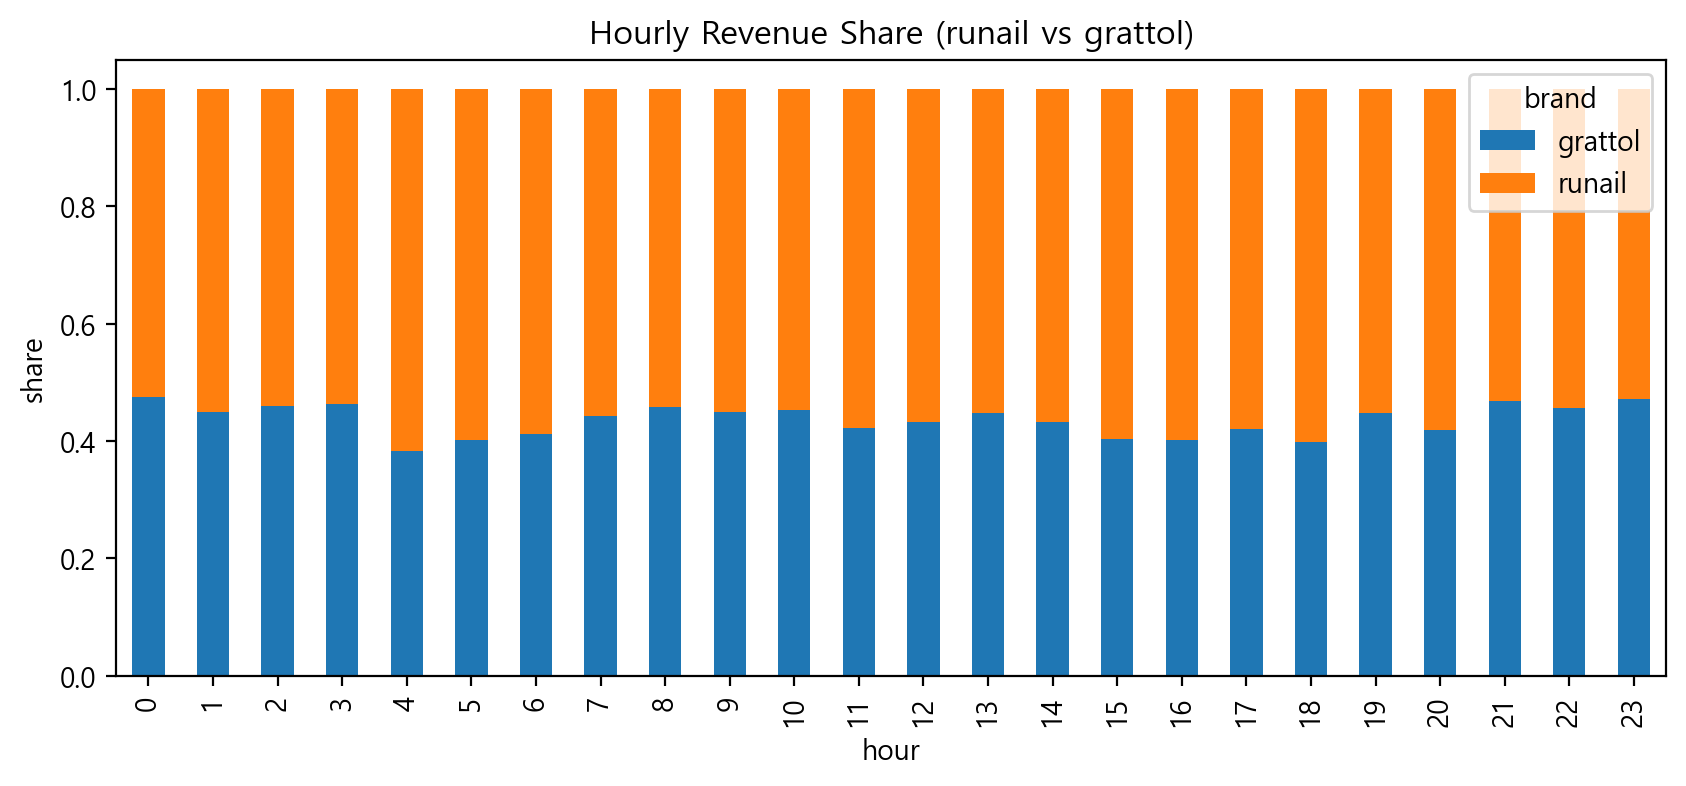

In [6]:
# 4) 시간대/요일 패턴 분석
purchase = df[df['event_type'] == 'purchase'].copy()
purchase = purchase[purchase['brand'].isin(['runail','grattol'])].copy()
purchase['brand'] = purchase['brand'].astype(str)

# 시간대/요일 컬럼
purchase['hour'] = purchase['event_time'].dt.hour
purchase['weekday'] = purchase['event_time'].dt.day_name()
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

# 시간대별 매출/주문
hourly = (purchase.groupby(['hour','brand'])
          .agg(revenue=('price','sum'),
               orders=('user_session','nunique'))
          .reset_index())

# 시간대별 매출 점유율
hour_share = (hourly.pivot(index='hour', columns='brand', values='revenue')
                     .fillna(0))
hour_share_pct = hour_share.div(hour_share.sum(axis=1), axis=0)

# 요일별 매출/주문
weekly = (purchase.groupby(['weekday','brand'])
          .agg(revenue=('price','sum'),
               orders=('user_session','nunique'))
          .reset_index())

# 요일별 매출 점유율
week_share = (weekly.pivot(index='weekday', columns='brand', values='revenue')
                    .fillna(0)
                    .reindex(weekday_order))
week_share_pct = week_share.div(week_share.sum(axis=1), axis=0)

# 시간대별 매출 추이
plt.figure(figsize=(10,4))
sns.lineplot(data=hourly, x='hour', y='revenue', hue='brand', marker='o')
plt.title('시간대별 매출 추이 (Grattol vs Runail)')
plt.xlabel('hour')
plt.ylabel('revenue')
plt.show()

# 시간대별 매출 점유율
hour_share_pct.plot(kind='bar', stacked=True, figsize=(10,4))
plt.title('Hourly Revenue Share (runail vs grattol)')
plt.ylabel('share')
plt.xlabel('hour')
plt.show()

주요 결정시간에 (2 ~ 4시) runail에게 눈에 띄게 밀린다

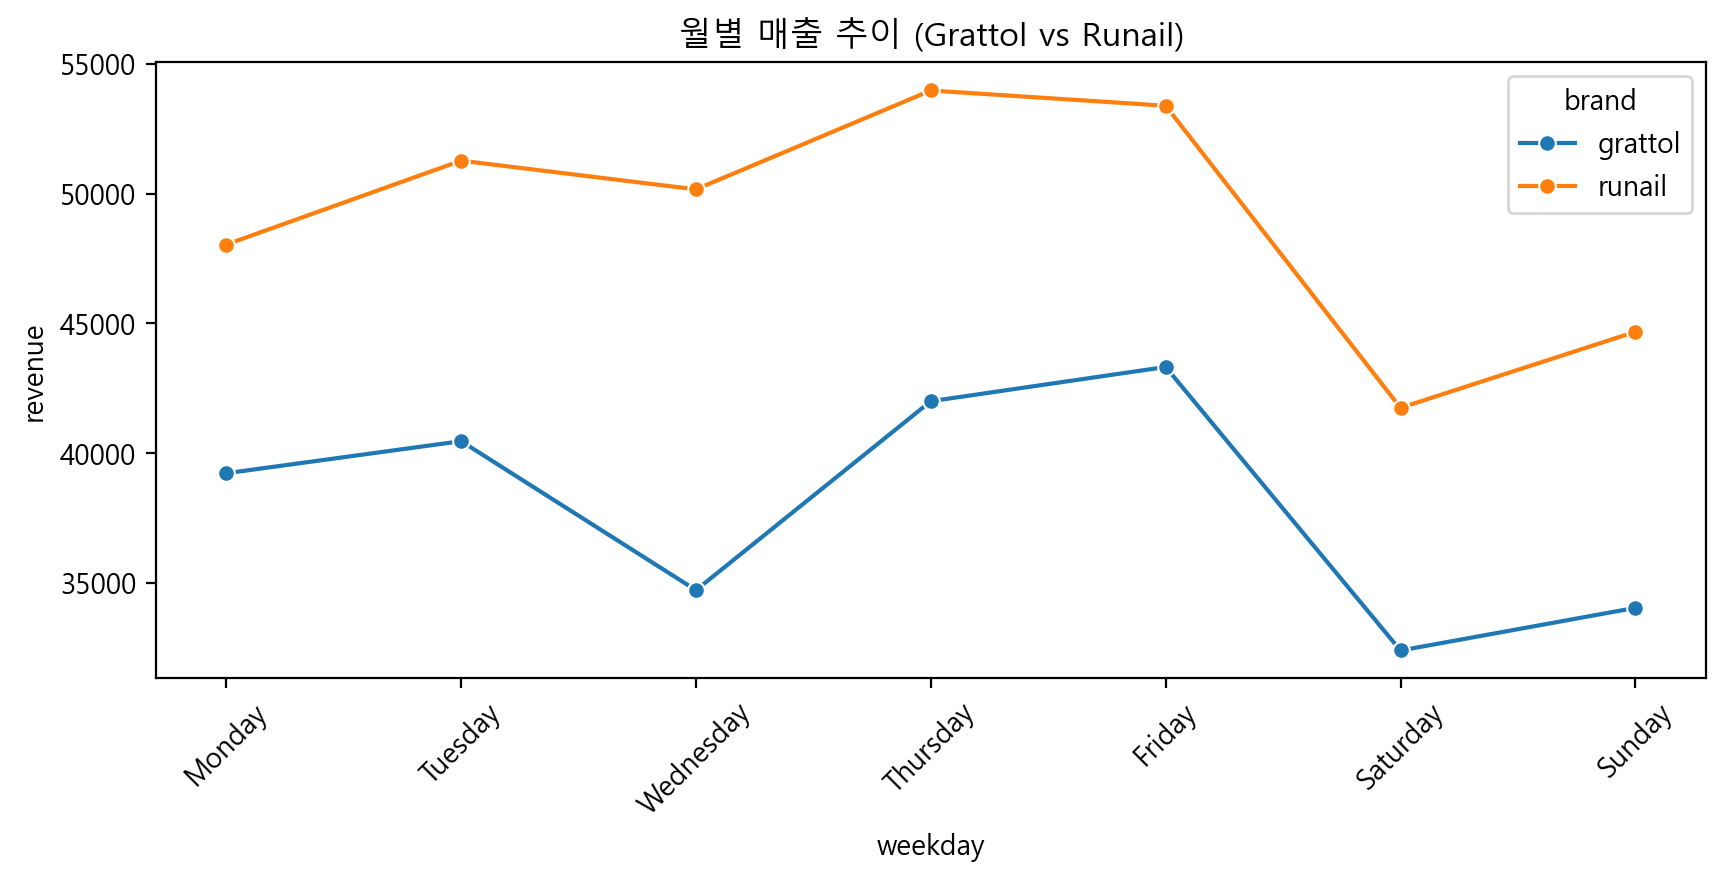

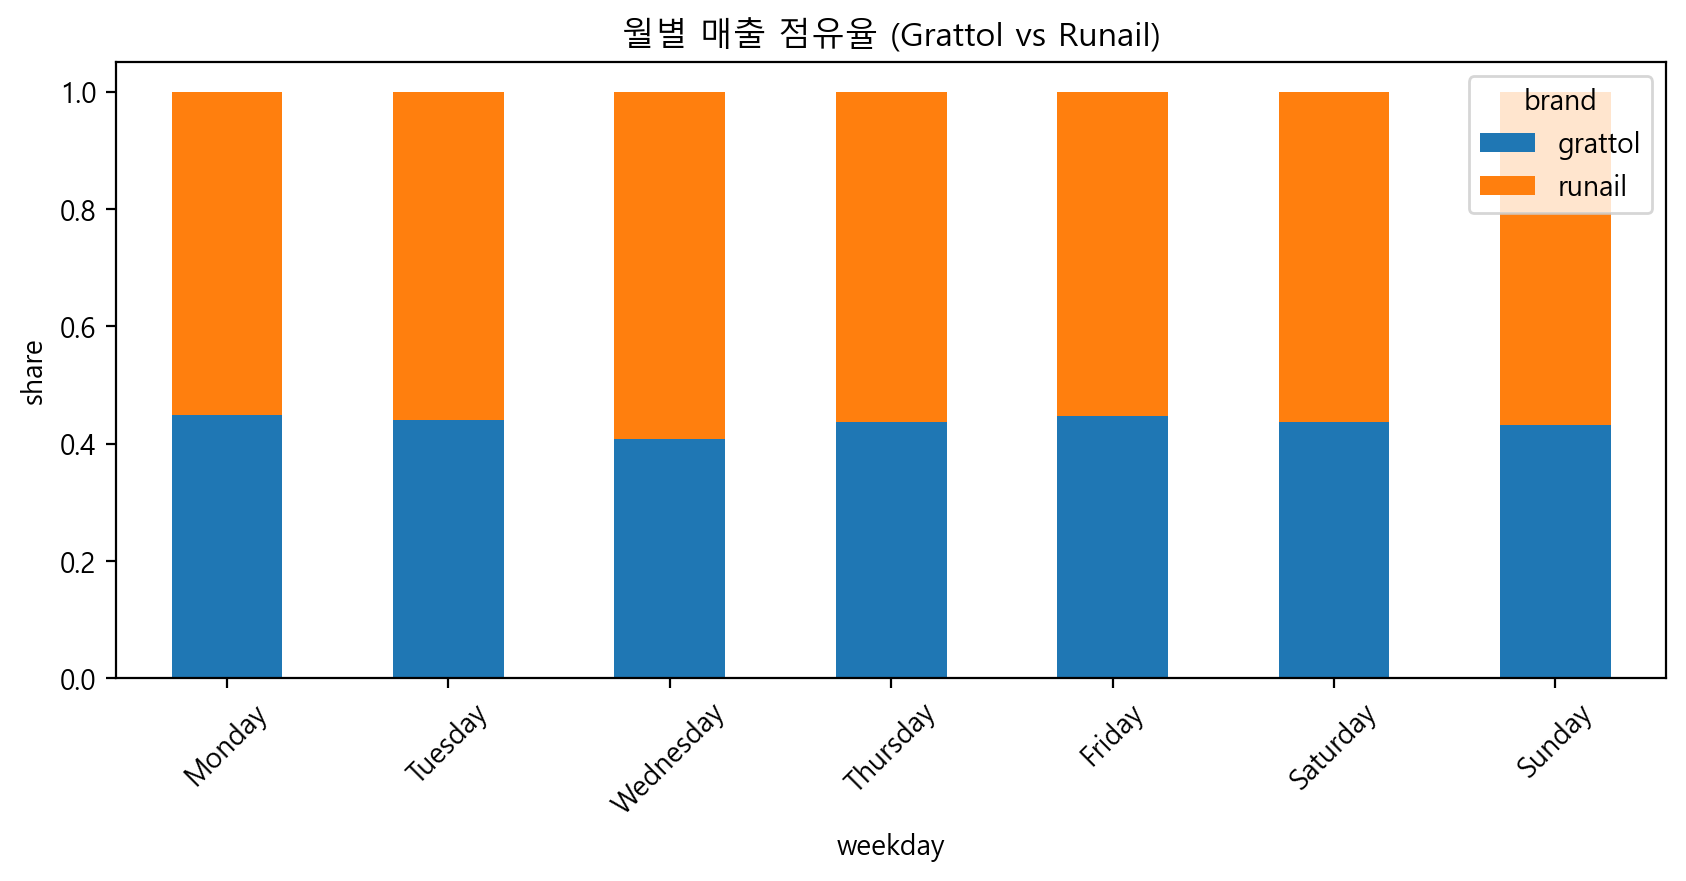

In [8]:
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

weekly = (purchase.groupby(['weekday','brand'])
          .agg(revenue=('price','sum'),
               orders=('user_session','nunique'))
          .reset_index())

# 요일 순서 고정
weekly['weekday'] = pd.Categorical(weekly['weekday'], categories=weekday_order, ordered=True)
weekly = weekly.sort_values('weekday')

# 요일별 매출 추이
plt.figure(figsize=(10,4))
sns.lineplot(data=weekly, x='weekday', y='revenue', hue='brand', marker='o')
plt.title('월별 매출 추이 (Grattol vs Runail)')
plt.xlabel('weekday')
plt.ylabel('revenue')
plt.xticks(rotation=45)
plt.show()

# 요일별 매출 점유율
week_share_pct.plot(kind='bar', stacked=True, figsize=(10,4))
plt.title('월별 매출 점유율 (Grattol vs Runail)')
plt.ylabel('share')
plt.xlabel('weekday')
plt.xticks(rotation=45)
plt.show()


수요일에 특히 선택받지 못하고 있음

In [19]:
# 브랜드별 퍼널 전환율 텍스트 출력
focus = df[df['brand'].isin(['runail','grattol'])].copy()
focus['brand'] = focus['brand'].astype(str)

funnel = (focus[focus['event_type'].isin(['view','cart','purchase'])]
          .groupby(['brand','event_type'])['user_session']
          .nunique()
          .unstack(fill_value=0))

def pct(x):
    return f"{x*100:.2f}%"

lines = []
for brand in ['grattol', 'runail']:
    view = funnel.loc[brand, 'view']
    cart = funnel.loc[brand, 'cart']
    purchase = funnel.loc[brand, 'purchase']

    cart_rate = cart / view if view else 0
    purchase_rate = purchase / view if view else 0
    purchase_from_cart = purchase / cart if cart else 0

    lines.append(f"[{brand}]")
    lines.append(f"- view -> cart 전환율: {pct(cart_rate)}")
    lines.append(f"- view -> purchase 전환율: {pct(purchase_rate)}")
    lines.append(f"- cart -> purchase 전환율: {pct(purchase_from_cart)}")
    lines.append("")

print("\n".join(lines))

[grattol]
- view -> cart 전환율: 36.08%
- view -> purchase 전환율: 9.47%
- cart -> purchase 전환율: 26.25%

[runail]
- view -> cart 전환율: 43.69%
- view -> purchase 전환율: 12.22%
- cart -> purchase 전환율: 27.98%



월별로 시각화해서 봐보자

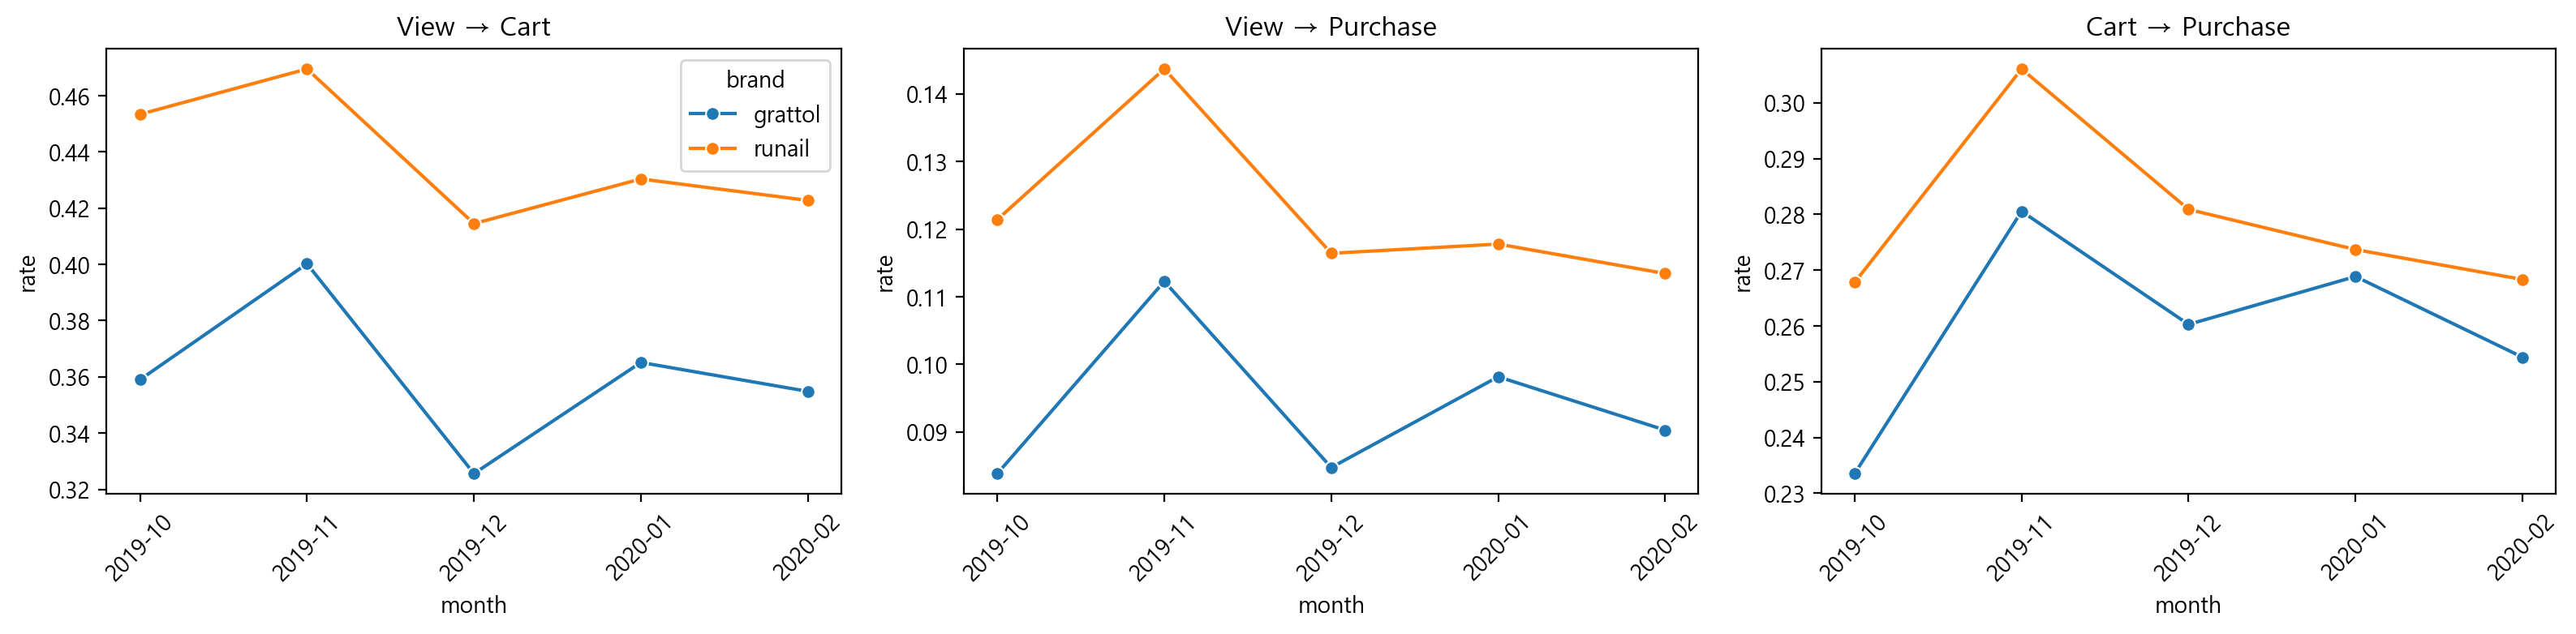

In [20]:
# 월별 퍼널 전환율 3축 그래프
focus = df[df['brand'].isin(['runail','grattol'])].copy()
focus['brand'] = focus['brand'].astype(str)
focus['month'] = focus['event_time'].dt.to_period('M').astype(str)

funnel = (focus[focus['event_type'].isin(['view','cart','purchase'])]
          .groupby(['month','brand','event_type'])['user_session']
          .nunique()
          .unstack(fill_value=0)
          .reset_index())

funnel['cart_rate'] = funnel['cart'] / funnel['view']
funnel['purchase_rate'] = funnel['purchase'] / funnel['view']
funnel['purchase_from_cart'] = funnel['purchase'] / funnel['cart']

# 월 순서 정렬
months = sorted(funnel['month'].unique())
funnel['month'] = pd.Categorical(funnel['month'], categories=months, ordered=True)
funnel = funnel.sort_values('month')

fig, axes = plt.subplots(1, 3, figsize=(16,4), sharex=True)

sns.lineplot(data=funnel, x='month', y='cart_rate', hue='brand', marker='o', ax=axes[0])
axes[0].set_title('View → Cart')
axes[0].set_ylabel('rate')
axes[0].set_xlabel('month')
axes[0].tick_params(axis='x', rotation=45)

sns.lineplot(data=funnel, x='month', y='purchase_rate', hue='brand', marker='o', ax=axes[1])
axes[1].set_title('View → Purchase')
axes[1].set_ylabel('rate')
axes[1].set_xlabel('month')
axes[1].tick_params(axis='x', rotation=45)

sns.lineplot(data=funnel, x='month', y='purchase_from_cart', hue='brand', marker='o', ax=axes[2])
axes[2].set_title('Cart → Purchase')
axes[2].set_ylabel('rate')
axes[2].set_xlabel('month')
axes[2].tick_params(axis='x', rotation=45)

# 범례 중복 제거
axes[1].legend_.remove()
axes[2].legend_.remove()

plt.tight_layout()
plt.show()

runail의 상품은 쉽게 구매결정이 이뤄지지만 비교적 고관여 제품이라 그런지<br>
grattol의 상품은 더 신중한 구매가 이뤄진다 <br>
(카트에서 구매가 이뤄지는 경우가 많다. 카트에 담았을 때 못 도망가게 하면 좋을 듯)

In [21]:
# 다른 날 재구매 기준
purchase = df[df['event_type'] == 'purchase'].copy()
purchase = purchase[purchase['brand'].isin(['runail','grattol'])].copy()
purchase['brand'] = purchase['brand'].astype(str)

# 구매 날짜(일 단위)
purchase['purchase_date'] = purchase['event_time'].dt.date

# 유저별 구매한 '일수' 계산
user_purchases = (purchase.groupby(['brand','user_id'])['purchase_date']
                  .nunique()
                  .reset_index(name='purchase_days'))

# 재구매 여부(다른 날 기준)
user_purchases['is_repeat'] = user_purchases['purchase_days'] >= 2

repeat_rate = (user_purchases.groupby('brand')['is_repeat']
               .mean()
               .reset_index(name='repeat_rate'))

# repeat_rate 텍스트 출력

print('재구매율')
for _, row in repeat_rate.iterrows():
    brand = row['brand']
    rate = row['repeat_rate'] * 100
    print(f"{brand}: {rate:.2f}%")

재구매율
grattol: 15.41%
runail: 17.24%


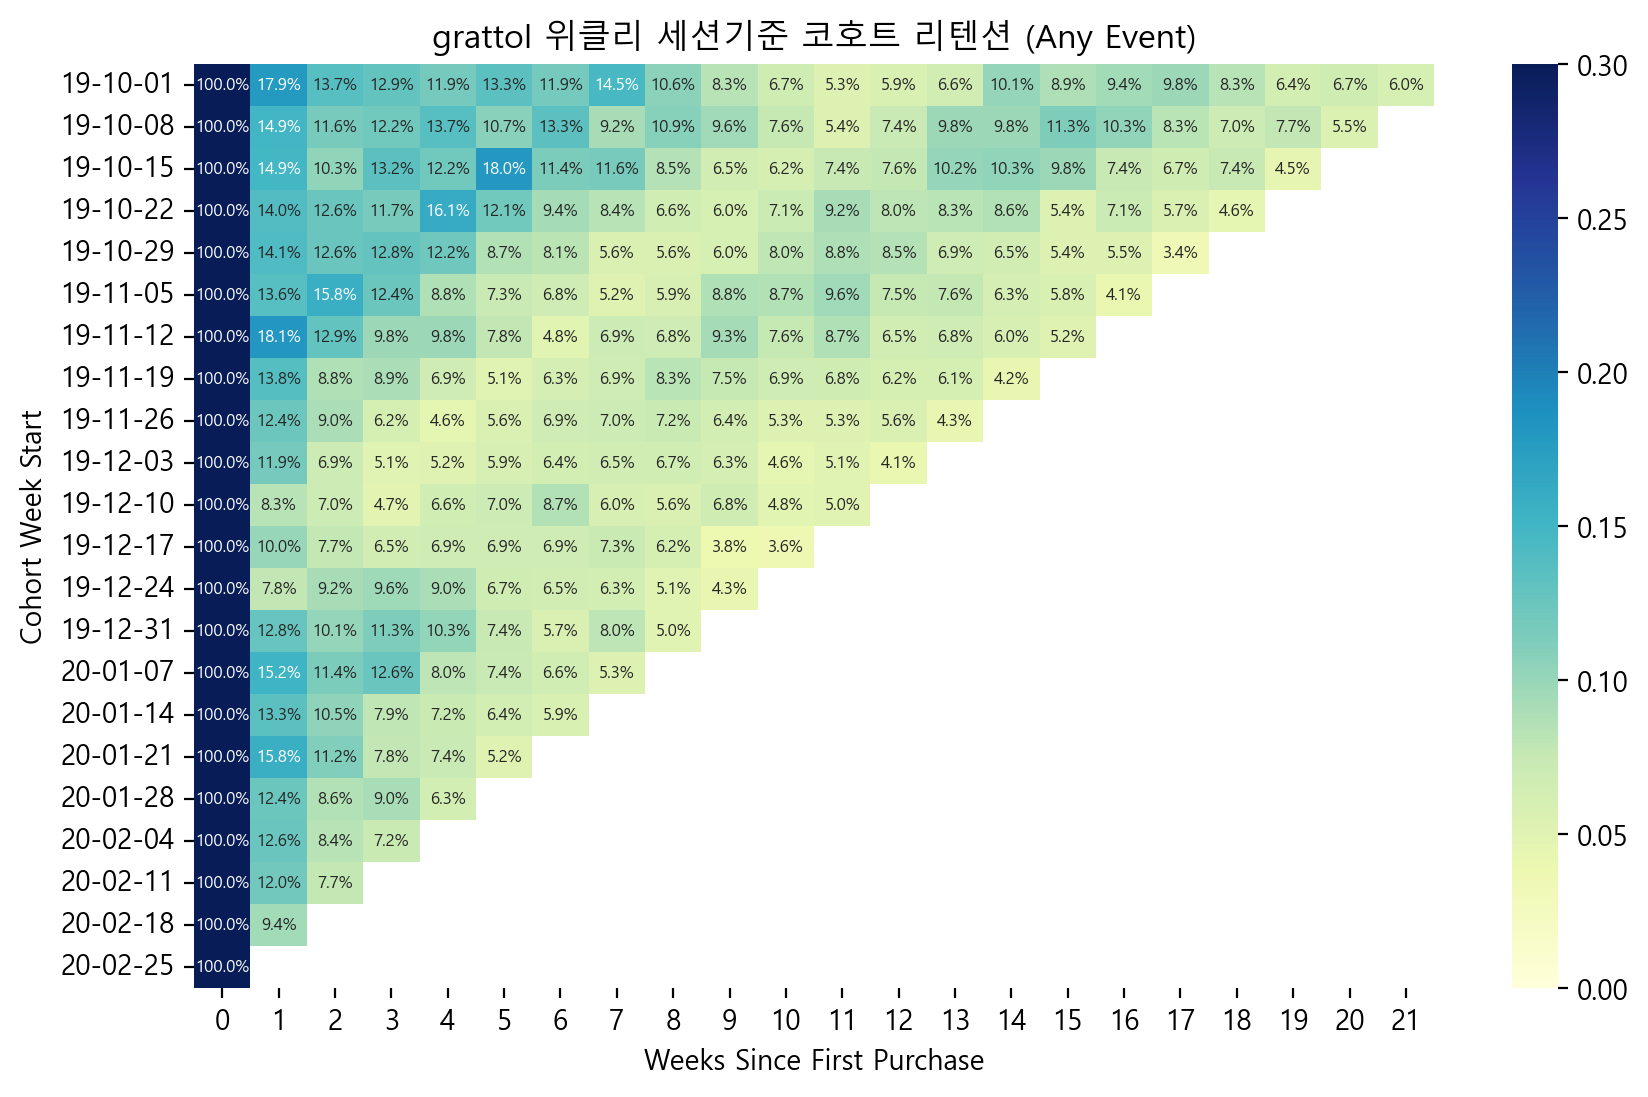

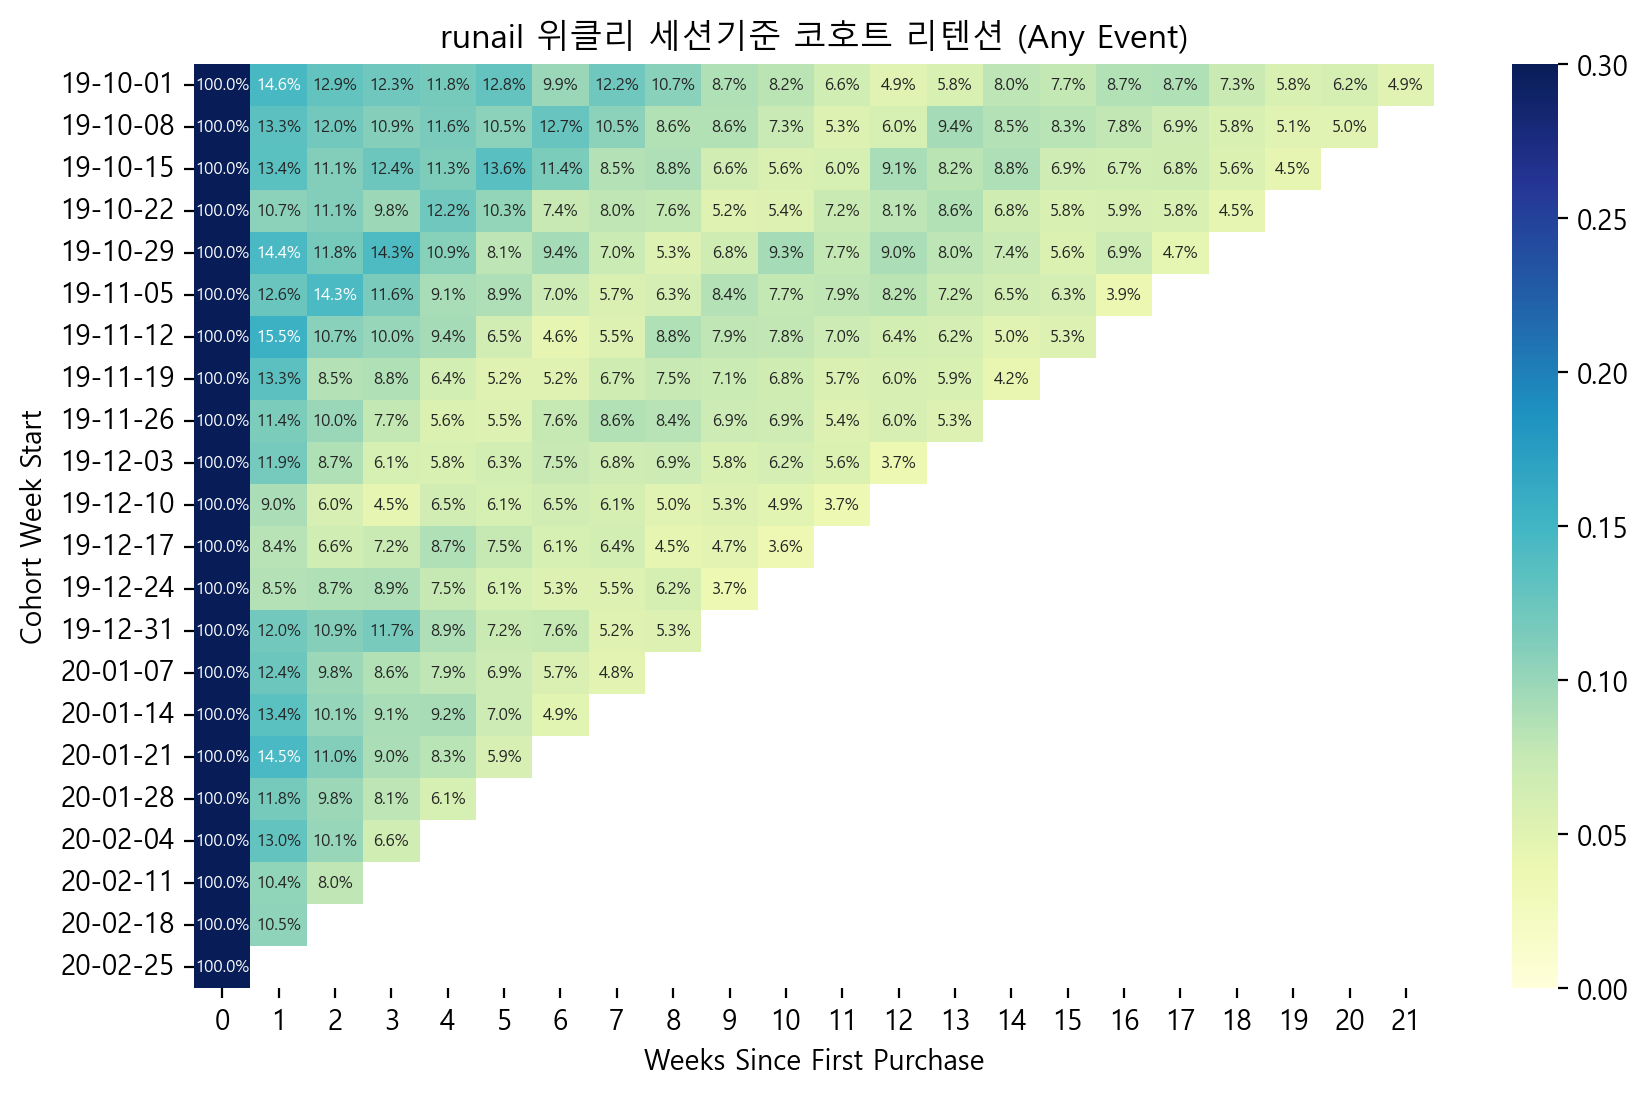

In [22]:
# 3) 세션 기준 재방문(주 단위)
focus = df[df['brand'].isin(['runail','grattol'])].copy()
focus['brand'] = focus['brand'].astype(str)

# 첫 구매 주
purchase = focus[focus['event_type'] == 'purchase'].copy()
purchase['order_week'] = purchase['event_time'].dt.to_period('W-MON')
first_purchase_week = (purchase.groupby(['brand','user_id'])['order_week']
                       .min()
                       .reset_index()
                       .rename(columns={'order_week':'cohort_week'}))

# 모든 이벤트를 주 단위로 묶어 재방문 여부 확인
focus['event_week'] = focus['event_time'].dt.to_period('W-MON')

# 코호트 기준 주차 계산
# week_index 음수 제거
merged = focus.merge(first_purchase_week, on=['brand','user_id'], how='inner')
merged['week_index'] = (
    (merged['event_week'].dt.start_time - merged['cohort_week'].dt.start_time).dt.days // 7
)
merged = merged[merged['week_index'] >= 0]


# 코호트별 주차 리텐션(재방문한 유저 비율)
ret = (merged.groupby(['brand','cohort_week','week_index'])['user_id']
       .nunique()
       .reset_index())

cohort_size = (ret[ret['week_index'] == 0]
               .rename(columns={'user_id':'cohort_users'})
               [['brand','cohort_week','cohort_users']])

ret = ret.merge(cohort_size, on=['brand','cohort_week'], how='left')
ret['retention'] = ret['user_id'] / ret['cohort_users']

# 히트맵
for brand in ['grattol','runail']:
    c = ret[ret['brand'] == brand].copy()
    c['cohort_week_start'] = c['cohort_week'].dt.start_time.dt.strftime('%y-%m-%d')
    pivot = c.pivot(index='cohort_week_start', columns='week_index', values='retention')

    plt.figure(figsize=(10,6))
    sns.heatmap(pivot,
        cmap="YlGnBu",
        vmin=0, vmax=0.3,
        annot=True, fmt=".1%",
        annot_kws={"size": 6},
        cbar=True
    )
    plt.title(f"{brand} 위클리 세션기준 코호트 리텐션 (Any Event)")
    plt.xlabel("Weeks Since First Purchase")
    plt.ylabel("Cohort Week Start")
    plt.show()


어떠한 이벤트로든 세션단위로 주별 재방문 하는 상황은 꽤 있다<br>
새해연휴기간동안은 확실히 유입이 적고, 연휴기간이 종료될때 쯤 리텐션이 높아지는 것을 볼 수 있다<br>
뿐만아니라 grattol의 경우 runail에 비해 한번이라도 구매를 한 고객이 꾸준히 눈팅을 하는 경우가 더 많은것을 확인 가능

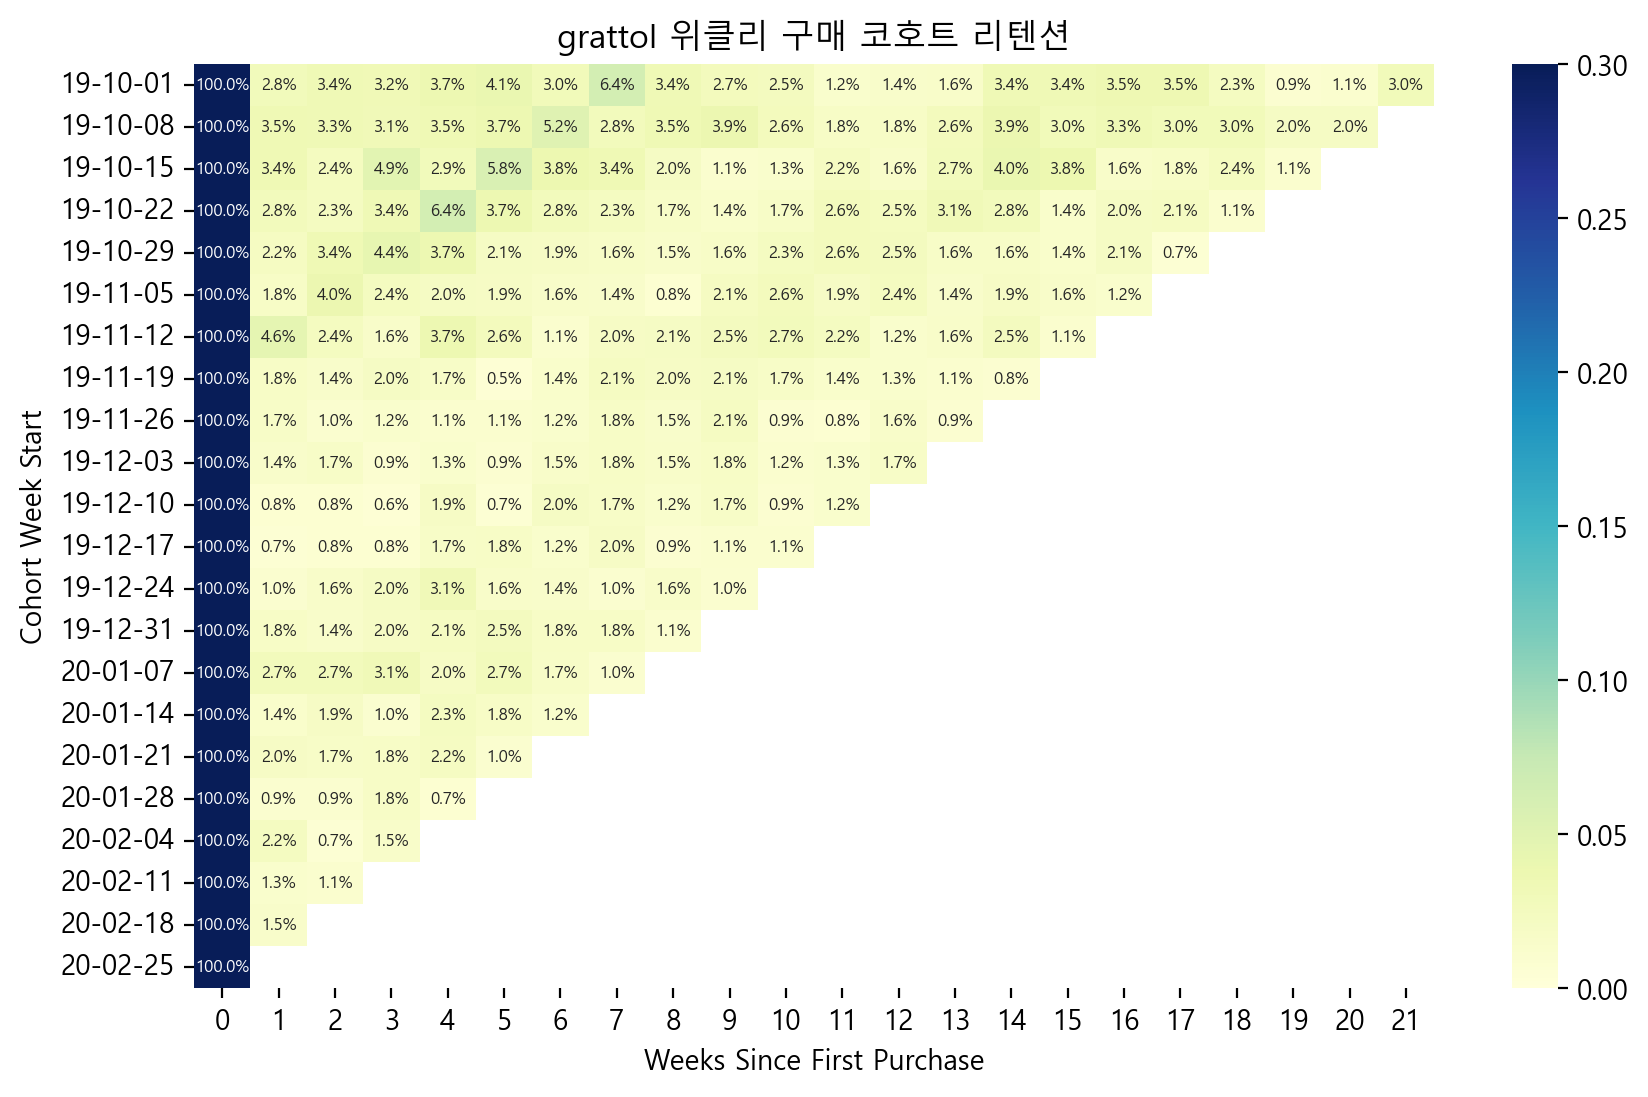

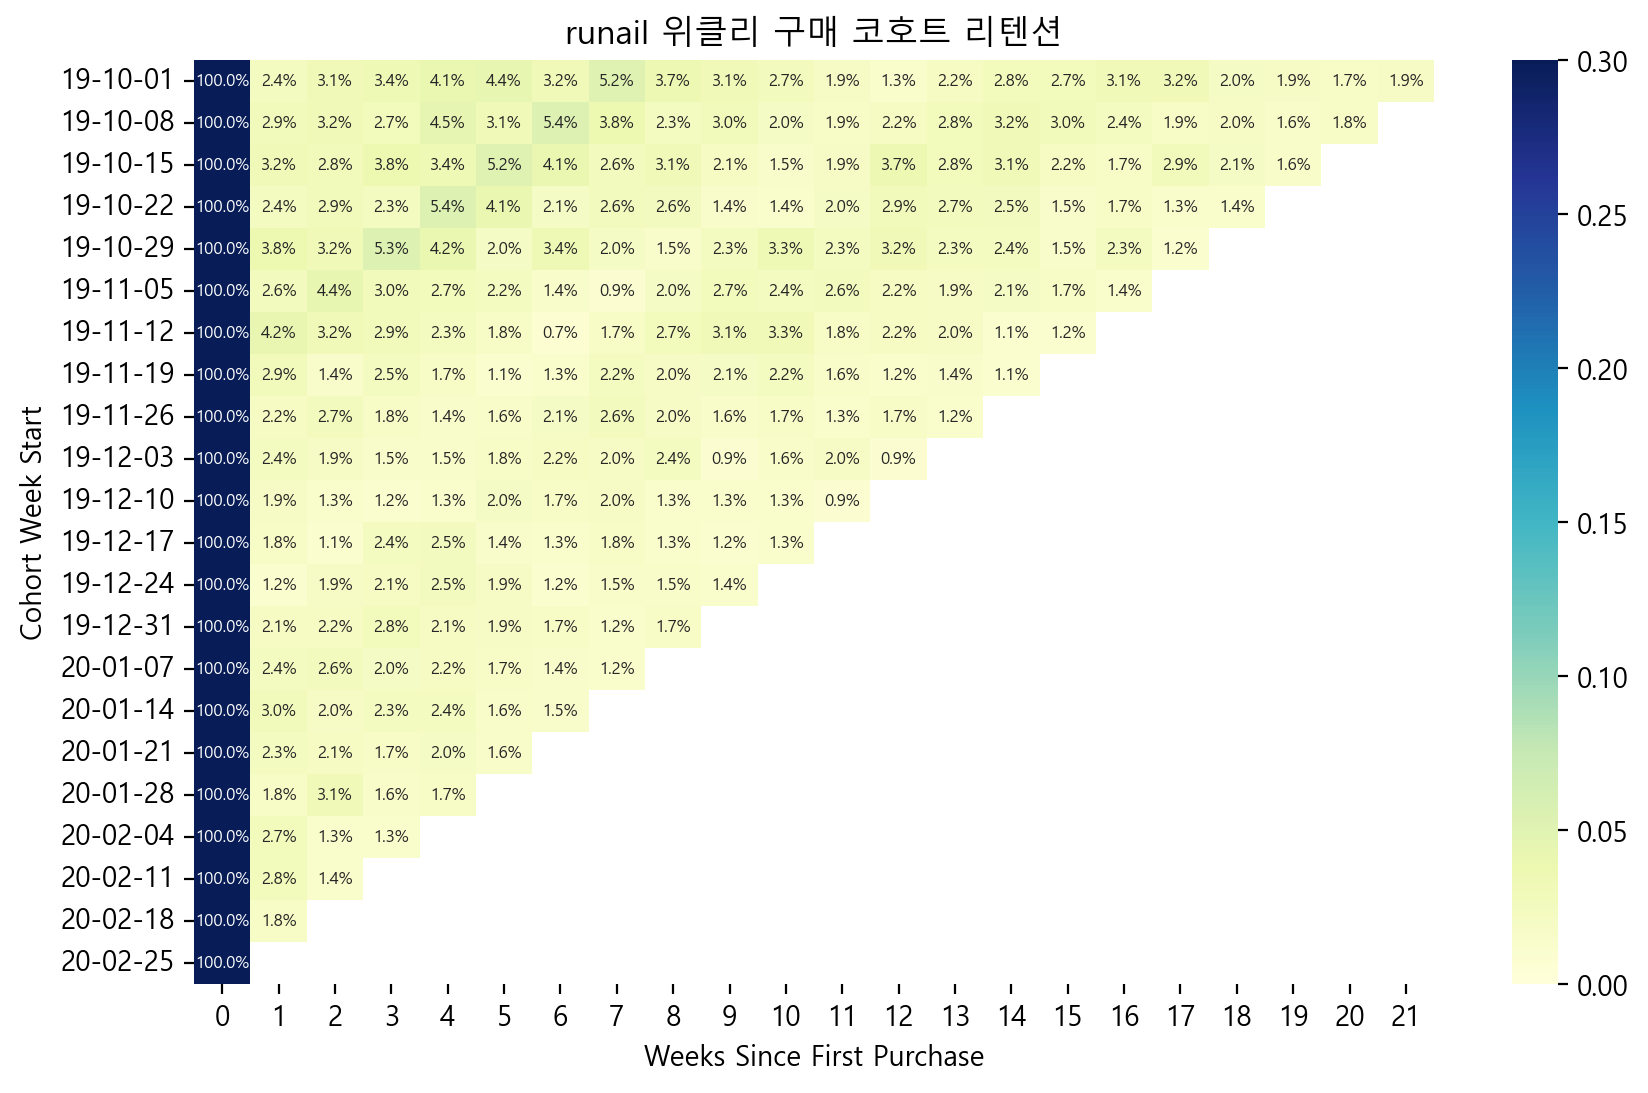

In [23]:
# 주간 구매 코호트 리텐션 (y축=주 시작일, 칸 안에 수치 표시)
purchase = df[df['event_type'] == 'purchase'].copy()
purchase = purchase[purchase['brand'].isin(['runail','grattol'])].copy()
purchase['brand'] = purchase['brand'].astype(str)

purchase['order_week'] = purchase['event_time'].dt.to_period('W-MON')
purchase['cohort_week'] = purchase.groupby(['brand','user_id'])['order_week'].transform('min')

purchase['week_index'] = (
    (purchase['order_week'].dt.start_time - purchase['cohort_week'].dt.start_time).dt.days // 7
)

cohort = (purchase.groupby(['brand','cohort_week','week_index'])['user_id']
          .nunique()
          .reset_index())

cohort_size = (cohort[cohort['week_index'] == 0]
               .rename(columns={'user_id':'cohort_users'})
               [['brand','cohort_week','cohort_users']])

cohort = cohort.merge(cohort_size, on=['brand','cohort_week'], how='left')
cohort['retention'] = cohort['user_id'] / cohort['cohort_users']

for brand in ['grattol','runail']:
    c = cohort[cohort['brand'] == brand].copy()
    # y축: 주 시작일만 (YY-MM-DD)
    c['cohort_week_start'] = c['cohort_week'].dt.start_time.dt.strftime('%y-%m-%d')
    pivot = c.pivot(index='cohort_week_start', columns='week_index', values='retention')

    plt.figure(figsize=(10,6))
    sns.heatmap(
        pivot,
        cmap="YlGnBu",
        vmin=0, vmax=0.3,
        annot=True, fmt=".1%",
        annot_kws={"size": 6},
        cbar=True
    )
    plt.title(f"{brand} 위클리 구매 코호트 리텐션")
    plt.xlabel("Weeks Since First Purchase")
    plt.ylabel("Cohort Week Start")
    plt.show()


러시아 여성들의 네일 주기는 평균 6개월이라고 한다 <br>
5개월 데이터에서는 코호트별로 단일 구매 B2C고객 + 꾸준 구매 B2B(전문가) 고객 으로 구성되어 있을 것으로 추정

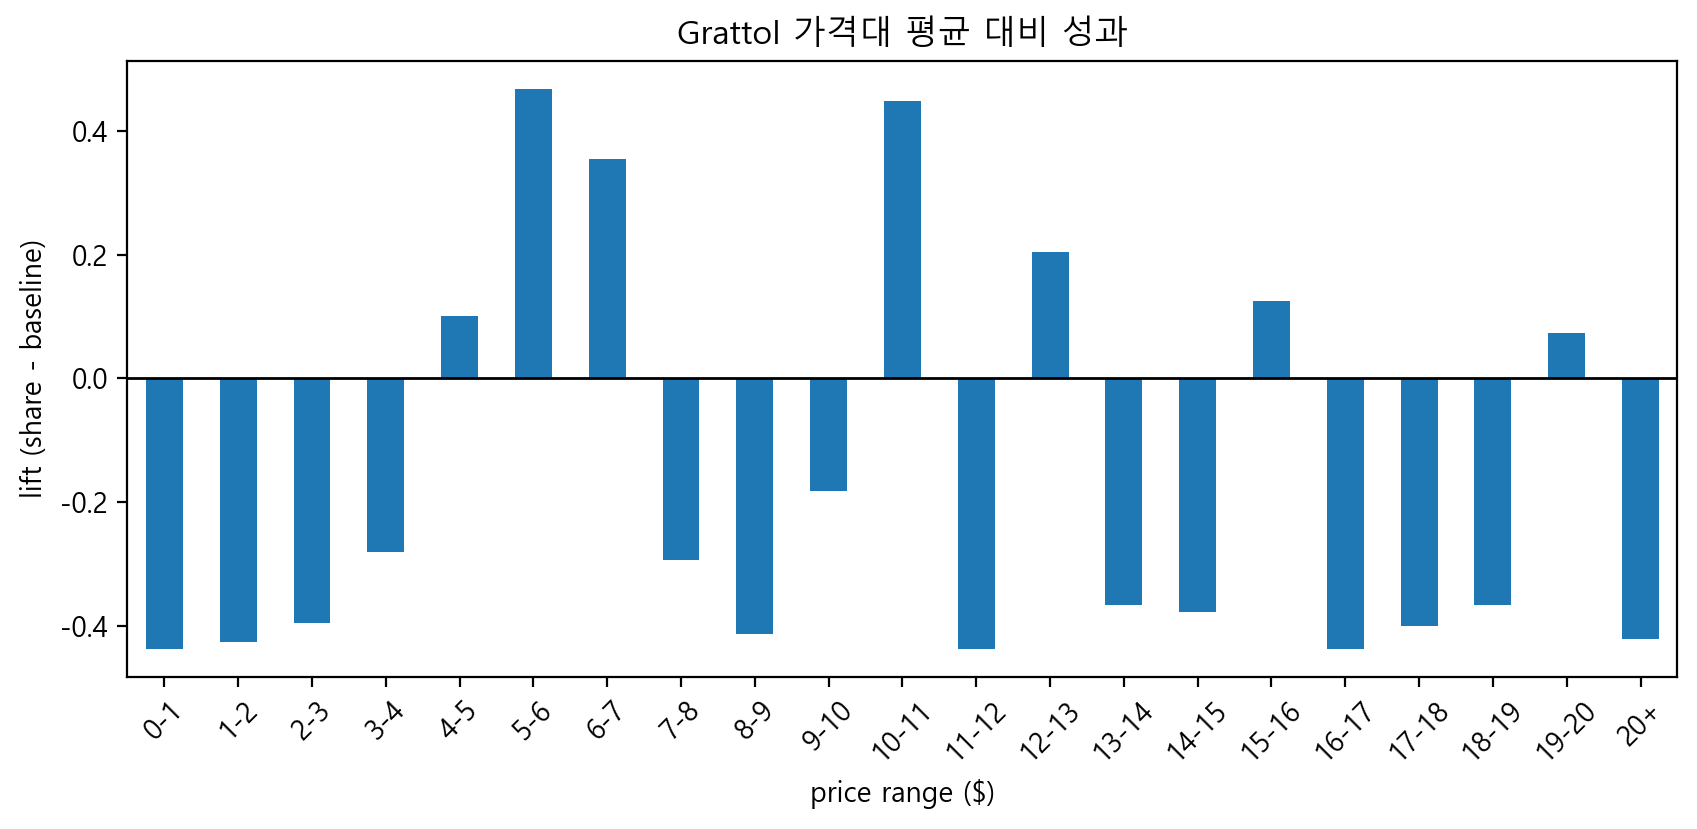

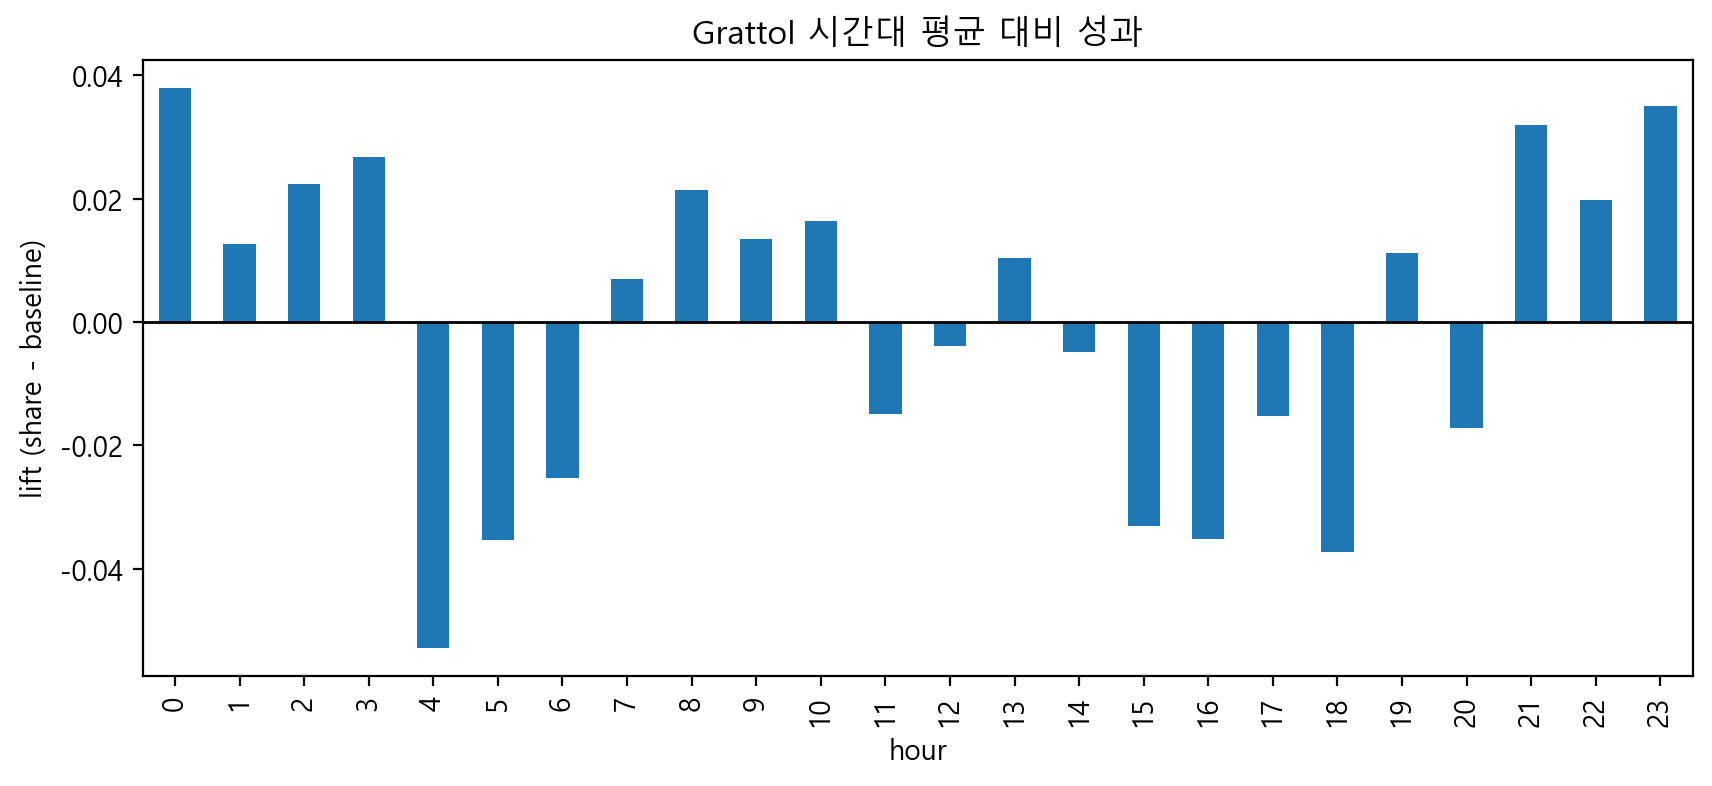

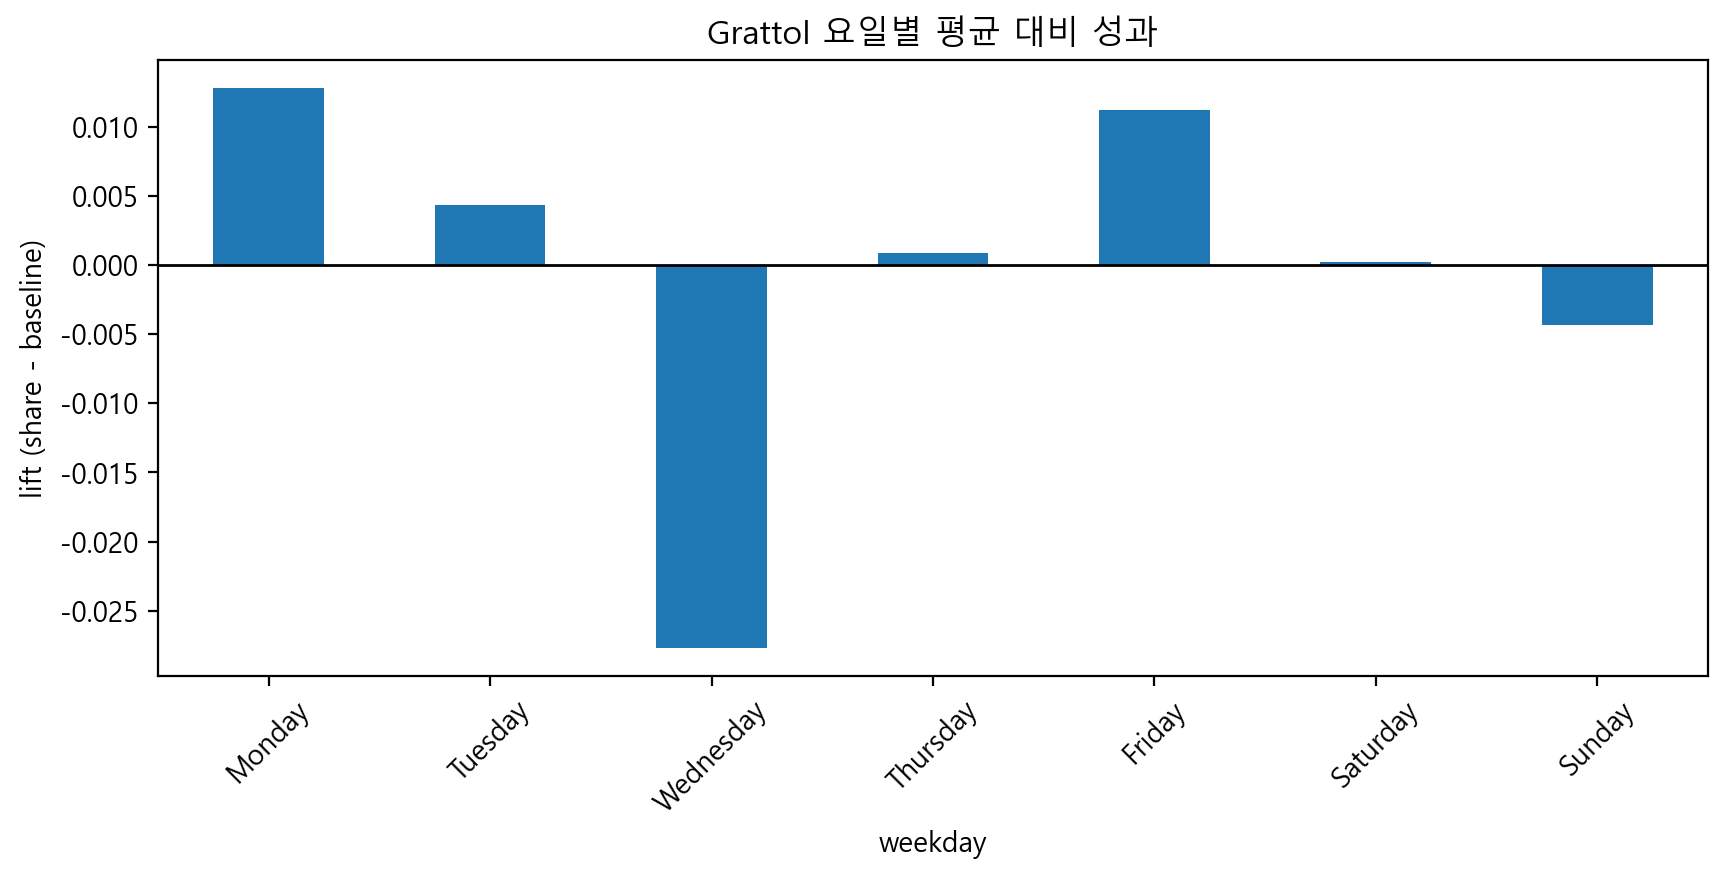

In [24]:
# grattol 평균 대비 성과 시각화 (가격대/시간대/요일)
# 0보다 크면 grattol이 평균보다 잘하는 구간, 0보다 작으면 약한 구간
purchase = df[df['event_type'] == 'purchase'].copy()
focus = purchase[purchase['brand'].isin(['runail','grattol'])].copy()
focus['brand'] = focus['brand'].astype(str)

# 전체 평균 점유율
total_rev = focus.groupby('brand')['price'].sum()
baseline_share = total_rev['grattol'] / total_rev.sum()

# 가격대 lift
bins = list(range(0, 21)) + [float('inf')]
labels = [f'{i}-{i+1}' for i in range(0, 20)] + ['20+']
focus['price_bin'] = pd.cut(focus['price'], bins=bins, labels=labels, right=False, include_lowest=True)

bin_rev = focus.groupby(['price_bin','brand'])['price'].sum().unstack(fill_value=0)
bin_share = bin_rev.div(bin_rev.sum(axis=1), axis=0)['grattol']
bin_lift = (bin_share - baseline_share).sort_index()

plt.figure(figsize=(10,4))
bin_lift.plot(kind='bar')
plt.axhline(0, color='k', linewidth=1)
plt.title('Grattol 가격대 평균 대비 성과')
plt.ylabel('lift (share - baseline)')
plt.xlabel('price range ($)')
plt.xticks(rotation=45)
plt.show()

# 시간대 lift
focus['hour'] = focus['event_time'].dt.hour
hour_rev = focus.groupby(['hour','brand'])['price'].sum().unstack(fill_value=0)
hour_share = hour_rev.div(hour_rev.sum(axis=1), axis=0)['grattol']
hour_lift = hour_share - baseline_share

plt.figure(figsize=(10,4))
hour_lift.plot(kind='bar')
plt.axhline(0, color='k', linewidth=1)
plt.title('Grattol 시간대 평균 대비 성과')
plt.ylabel('lift (share - baseline)')
plt.xlabel('hour')
plt.show()

# 요일 lift
focus['weekday'] = focus['event_time'].dt.day_name()
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
week_rev = focus.groupby(['weekday','brand'])['price'].sum().unstack(fill_value=0)
week_share = week_rev.div(week_rev.sum(axis=1), axis=0)['grattol']
week_lift = (week_share - baseline_share).reindex(weekday_order)

plt.figure(figsize=(10,4))
week_lift.plot(kind='bar')
plt.axhline(0, color='k', linewidth=1)
plt.title('Grattol 요일별 평균 대비 성과')
plt.ylabel('lift (share - baseline)')
plt.xlabel('weekday')
plt.xticks(rotation=45)
plt.show()

## runail과 평균대비 성과를 보면, 가장 노른자 타이밍일때 딸린다

## Get(Winner) - Grattol 장바구니 전환 최종구매 매출 기여도 (vs. Runail)

In [ ]:
# 1. 실제 구매(purchase) 데이터만 추출
purchase_df = df[df['event_type'] == 'purchase'].copy()

# 2. Get 케이스를 발생시킨 유저 리스트 추출
switching_users = get_cases['user_id'].unique()

# 3. 이 유저들이 실제로 구매까지 완료했는지 매칭
# 브랜드 전환 후 구매까지 이어진 '최종 승리' 케이스
switching_purchases = purchase_df[
    (purchase_df['user_id'].isin(switching_users)) & 
    (purchase_df['brand'] == 'grattol')
]

# 4. 결과 지표 산출
total_switching_users = len(switching_users)
converted_to_purchase = switching_purchases['user_id'].nunique()
purchase_conversion_rate = (converted_to_purchase / total_switching_users) * 100
total_revenue_from_get = switching_purchases['price'].sum()

print(f"브랜드 전환 유저의 구매 전환 분석")
print(f"1. Runail에서 Grattol로 갈아탄 유저 수: {total_switching_users:,}명")
print(f"2. 그 중 실제 Grattol 제품을 구매한 유저 수: {converted_to_purchase:,}명")
print(f"3. 최종 구매 전환율(CVR): {purchase_conversion_rate:.2f}%")
print(f"4. 전환 유저를 통한 총 매출 기여도: ${total_revenue_from_get:,.2f}")

## Loss(Loser) - Grattol 이탈 후 Runail로의 이탈 고객의 매출 기여도 (vs. Runail)

In [ ]:
# 1. Loss 케이스를 발생시킨 유저 리스트 추출
loss_users = loss_cases['user_id'].unique()

# 2. 이 유저들이 실제로 Runail 제품을 구매했는지 매칭
# 우리를 버리고 경쟁사 매출을 올려준 '뼈아픈' 케이스
loss_purchases = purchase_df[
    (purchase_df['user_id'].isin(loss_users)) & 
    (purchase_df['brand'] == 'runail')
]

# 3. 결과 지표 산출
total_loss_users = len(loss_users)
converted_to_runail = loss_purchases['user_id'].nunique()
loss_conversion_rate = (converted_to_runail / total_loss_users) * 100
total_revenue_lost = loss_purchases['price'].sum()

print(f"브랜드 이탈 유저의 구매 전환 분석")
print(f"1. Grattol에서 Runail로 갈아탄 유저 수: {total_loss_users:,}명")
print(f"2. 그 중 실제 Runail 제품을 구매한 유저 수: {converted_to_runail:,}명")
print(f"3. 경쟁사 구매 전환율: {loss_conversion_rate:.2f}%")
print(f"4. 경쟁사로 유출된 추정 매출액: ${total_revenue_lost:,.2f}")

In [ ]:
# 1) 구매 데이터만
p = df[df["event_type"] == "purchase"].copy()

# 2) 브랜드 표기 통일 (대/소문자, 공백)
p["brand"] = p["brand"].str.strip().str.lower()

# 3) 시간 순 정렬
p["event_time"] = pd.to_datetime(p["event_time"], format="mixed", utc=True)
p = p.sort_values(["user_id", "event_time"])

# 4) 직전 구매 브랜드
p["prev_brand"] = p.groupby("user_id")["brand"].shift(1)

# 5) 갈아탐 이벤트만 추출
switch = p[(p["prev_brand"].notna()) & (p["prev_brand"] != p["brand"])].copy()

# 6) Runail -> Grattol / Grattol -> Runail 필터
switch_rg = switch[(switch["prev_brand"] == "runail") & (switch["brand"] == "grattol")]
switch_gr = switch[(switch["prev_brand"] == "grattol") & (switch["brand"] == "runail")]

# 7) 주별 집계 (갈아탄 시점의 주)
switch_rg["week"] = switch_rg["event_time"].dt.to_period("W")
switch_gr["week"] = switch_gr["event_time"].dt.to_period("W")

rg_week = switch_rg.groupby("week").size()
gr_week = switch_gr.groupby("week").size()

weekly = pd.DataFrame({
    "Runail->Grattol": rg_week,
    "Grattol->Runail": gr_week
}).fillna(0).astype(int)

weekly

weekly.index = weekly.index.to_timestamp()
weekly.plot(figsize=(12,6), marker="o")
plt.title("주별 브랜드 전환 추이")
plt.xlabel("Week")
plt.ylabel("Number of Switches")
plt.xticks(rotation=45)
plt.show()

프로모션 아이디어 <br>
서칭이 잦은 밤시간(22~23시) 집중 광고 노출<br>
카트에 담았을 때 못도망가게 장바구니 프로모션 하기<br>

노른자 타이밍인 수요일 프로모션<br>
2~4시 타임세일<br>

머신러닝 아이디어 (분류,예측) <br>

분류<br>
kmeans를 활용하여 타겟선정 후 이러이러한 타겟친화적 프로모션들로 <br>



예측<br>
시계열예측으로 하락추세를 보여주면서 전환국면 필요성을 어필<br>
이탈의 ~%를 막을 수 있으면 얼마의 이익을 낼 수 있다는 방향으로 말한다면?

---

### 고가,저가상품의 장바구니 생존에 관하여

고가상품 - 높은 구매의사결정 - 장바구니 삭제가 거의없음<br>
저가상품 - 비교적 자주 장바구니에서 삭제됨<br>

그래서 매우 약한 음의 상관관계를 띔 <br>
(가격과 삭제율 간의 상관계수: -0.1112)

이 논리는 사용이 어려움 (저가살품에 케이스가 많음, 데이터불균형)<br>
